# FR 2016 Singles RURO — Production Pipeline (P2a certified B-pool draws, region-live)

Linear, re-runnable singles pipeline distilled from the exploratory `fr_data_walkthrough.ipynb`
(kept as the historical record — **do not** delete it). Only the *final* path survives here:
certified B-pool draws (D1 hours mixture, W1 occupation-conditional wages, empirical occupation,
pi0=0.10, seed 2026), bsa00yn_a=1 deterministic pricing, bpool band convention, region/urbanisation/
gsur revived onto the engine-ready frame (§12b), and the fit with the 10 couples/year params pinned
and the **occupation block free**.

**Regression anchor:** the pipeline reproduces the region-live P2a negLL **19053.4655**. (The earlier
region-*dead* fit, 19071.6562, left `beta_E` absorbing regional variation; reviving the regional
covariates lowers negLL by ~18 and moves `beta_E` −4.31 → −2.90.)

**Welfare (§19):** the final section produces V_i^IS and the W1/W3/W4/W6 welfare-measure family plus
the survey-weighted inequality battery on this baseline (P3-1), by running the two `scripts/welfare/`
tools and verifying the outputs are region-live.

**SKIP_PRICING** — EUROMOD pricing is guarded. With `SKIP_PRICING=True` the pricing cells load the
cached parquets in `fr_singles_pricing_p2a/` instead of calling EUROMOD; set `False` to reprice.
A dropped-cells appendix at the end lists every exploratory/superseded cell removed and why.

In [1]:
# ── Setup, flags, and raw read ──────────────────────────────────────────────
import sys, time, json
import numpy as np
import pandas as pd
from pathlib import Path
pd.set_option('display.max_columns', 80); pd.set_option('display.width', 200)

# Load pricing / EUROMOD cells from cache instead of calling EUROMOD when True.
SKIP_PRICING = True

# repo root + the certified draw modules (they cross-import by bare name).
MNL_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'scripts/bpool/build_bpool_singles.py').exists()), None)
assert MNL_ROOT, 'MNL repo root not found'
import os; os.chdir(MNL_ROOT)   # all relative artifacts (pricing cache, outputs/, parquets) resolve at repo root
for sub in ('scripts/bpool', 'scripts/pilot'):
    d = str(MNL_ROOT / sub)
    if d not in sys.path: sys.path.insert(0, d)

FR_RAW = Path('C:/Users/hisham/MNL/EUROMOD-STORAGE/Data/FR/FR_2016_a3.txt')
raw = pd.read_csv(FR_RAW, sep='\t')
print('raw shape   :', raw.shape, '| households:', raw['idhh'].nunique(), '| persons:', len(raw))

raw shape   : (26560, 124) | households: 11459 | persons: 26560


## 1. Schema check — confirm the EUROMOD-standard + FR-specific columns are present

In [2]:
# key model inputs + the FR-specific columns the pipeline depends on
_need = ['idhh','idperson','idpartner','dag','dgn','les','lhw','deh','loc','yivwg','yem','yse']
_fr   = ['drgn1','drgur','drgmd','drgru','yem00','yemxp','lma','liwwh','dew','dey','bsa00','bsa00_s']
print('required present :', {c: (c in raw.columns) for c in _need})
print('FR-specific      :', {c: (c in raw.columns) for c in _fr})
assert all(c in raw.columns for c in _need), 'missing a required EUROMOD input column'

required present : {'idhh': True, 'idperson': True, 'idpartner': True, 'dag': True, 'dgn': True, 'les': True, 'lhw': True, 'deh': True, 'loc': True, 'yivwg': True, 'yem': True, 'yse': True}
FR-specific      : {'drgn1': True, 'drgur': True, 'drgmd': True, 'drgru': True, 'yem00': True, 'yemxp': True, 'lma': False, 'liwwh': True, 'dew': True, 'dey': True, 'bsa00': True, 'bsa00_s': False}


## 2. Eligibility config (FR-mirror constants, from the DE adapter)

In [3]:
CONFIG = dict(
    age_range=(20, 60),
    allowed_les=(3, 5, 7),               # employee / unemployed / inactive deciders
    wage_bounds=(2.0, 170.0),            # employee-decider yivwg bounds
    other_member_income_threshold=50.0,  # |yem|/|yse| above this = earning non-decider
    hours_cap_high=70, hours_floor_low=10, hours_inactive_threshold=5,
    retire_cols=('byr', 'pdi', 'poa', 'psu'),   # CONFIRM FR benefit-receipt columns
)
CONFIG

{'age_range': (20, 60),
 'allowed_les': (3, 5, 7),
 'wage_bounds': (2.0, 170.0),
 'other_member_income_threshold': 50.0,
 'hours_cap_high': 70,
 'hours_floor_low': 10,
 'hours_inactive_threshold': 5,
 'retire_cols': ('byr', 'pdi', 'poa', 'psu')}

## 3. Classify households (single / opposite-sex couple)

In [4]:
ADULT = CONFIG['age_range'][0]
dag = pd.to_numeric(raw['dag'], errors='coerce').fillna(-1)
idp = pd.to_numeric(raw['idpartner'], errors='coerce').fillna(0).astype('int64')
id2partner = dict(zip(raw['idperson'].astype('int64'), idp))
idset = set(raw['idperson'].astype('int64'))

def _mutual(a, b):
    return b != 0 and b in idset and id2partner.get(b, 0) == a

cls = {}
for hh, g in raw.groupby('idhh'):
    ad = g[pd.to_numeric(g['dag'], errors='coerce') >= ADULT]
    n = len(ad)
    if n == 0:
        cls[hh] = 'excl_no_adult'
    elif n == 1:
        cls[hh] = 'single' if int(ad['idpartner'].iloc[0]) == 0 else 'excl_2adult_no_link'
    elif n == 2:
        a, b = ad['idperson'].astype('int64').tolist()
        if _mutual(a, b) and _mutual(b, a):
            gens = sorted(pd.to_numeric(ad['dgn'], errors='coerce').tolist())
            cls[hh] = 'couple_mf' if gens == [0, 1] else 'excl_same_sex'
        else:
            cls[hh] = 'excl_2adult_no_link'
    else:
        cls[hh] = 'excl_3plus_adults'

raw['household_class'] = raw['idhh'].map(cls)
raw['ruro_decider'] = (raw['household_class'].isin(['single', 'couple_mf'])
                       & (pd.to_numeric(raw['dag'], errors='coerce') >= ADULT)).astype(int)
print(raw.groupby('idhh')['household_class'].first().value_counts())
print('\ndeciders flagged:', int(raw['ruro_decider'].sum()))

household_class
couple_mf              5965
single                 4038
excl_3plus_adults       930
excl_2adult_no_link     452
excl_same_sex            53
excl_no_adult            21
Name: count, dtype: int64

deciders flagged: 15968


## 4. The eligibility chain — one step per cell (household funnel printed at each step)

In [5]:
def funnel(df, label):
    print(f'{label:48s} households={df["idhh"].nunique():6d}  persons={len(df):6d}')
    return df

def keep_all_deciders(df, cond):
    """Keep a household only if EVERY decider satisfies cond."""
    dec = df['ruro_decider'] == 1
    bad = df.loc[dec & ~cond.reindex(df.index), 'idhh']
    return df[~df['idhh'].isin(pd.unique(bad))].copy()

def drop_hh(df, bad_idhh):
    return df[~df['idhh'].isin(pd.unique(bad_idhh))].copy()

# Step 4.0 — baseline: singles + opposite-sex couples only
work = raw[raw['household_class'].isin(['single', 'couple_mf'])].copy()
funnel(work, '4.0 baseline (single + couple_mf)');

4.0 baseline (single + couple_mf)                households= 10003  persons= 21842


In [6]:
# Step 4.1 — age: every decider in [20, 60]
lo, hi = CONFIG['age_range']
dag = pd.to_numeric(work['dag'], errors='coerce')
work = keep_all_deciders(work, dag.between(lo, hi))
funnel(work, '4.1 age (all deciders 20-60)');

4.1 age (all deciders 20-60)                     households=  5793  persons= 15252


In [7]:
# Step 4.2 — education: every decider dec == 0 (not currently in education)
if 'dec' in work.columns:
    dec = pd.to_numeric(work['dec'], errors='coerce')
    work = keep_all_deciders(work, dec.eq(0))
funnel(work, '4.2 education (deciders dec==0)');

4.2 education (deciders dec==0)                  households=  5557  persons= 14701


In [8]:
# Step 4.3 — retirement/disability: HH sum of (byr+pdi+poa+psu) == 0
# CONFIRM these are the right FR benefit-receipt columns (DE adapter used these four).
rc = [c for c in CONFIG['retire_cols'] if c in work.columns]
print('retire cols used:', rc)
if rc:
    retire = work[rc].apply(pd.to_numeric, errors='coerce').fillna(0.0).sum(axis=1)
    work['_retire'] = retire
    hh_retire = work.groupby('idhh')['_retire'].sum()
    work = drop_hh(work, hh_retire.index[hh_retire > 0]).drop(columns='_retire')
funnel(work, '4.3 retirement/disability (HH sum == 0)');

retire cols used: ['pdi', 'poa', 'psu']
4.3 retirement/disability (HH sum == 0)          households=  4973  persons= 13521


In [9]:
# Step 4.4 — allowed labour status: every decider les in {3, 5, 7}
les = pd.to_numeric(work['les'], errors='coerce')
work = keep_all_deciders(work, les.isin(CONFIG['allowed_les']))
funnel(work, '4.4 allowed LES (deciders in {3,5,7})');

4.4 allowed LES (deciders in {3,5,7})            households=  4010  persons= 10369


In [10]:
# Step 4.5 — other household members: drop HH if any NON-decider is
#   working-age-healthy-not-student  OR  earning (|yem| or |yse| > threshold)
lo, hi = CONFIG['age_range']; thr = CONFIG['other_member_income_threshold']
nondec = work['ruro_decider'] == 0
dag = pd.to_numeric(work['dag'], errors='coerce')
ddi = pd.to_numeric(work.get('ddi', 0), errors='coerce').fillna(0)
dec = pd.to_numeric(work.get('dec', 0), errors='coerce').fillna(0)
yem = pd.to_numeric(work.get('yem', 0.0), errors='coerce').fillna(0.0)
yse = pd.to_numeric(work.get('yse', 0.0), errors='coerce').fillna(0.0)
capable = dag.between(lo, hi) & ddi.eq(0) & dec.eq(0)
earning = (yem > thr) | (yse.abs() > thr)
work = drop_hh(work, work.loc[nondec & (capable | earning), 'idhh'])
funnel(work, '4.5 other members (no capable/earning non-deciders)');

4.5 other members (no capable/earning non-deciders) households=  3887  persons=  9922


In [11]:
# Step 4.6 — hours cap + inactive transition + wage bounds (employee deciders, les==3)
cap, floor, inact = CONFIG['hours_cap_high'], CONFIG['hours_floor_low'], CONFIG['hours_inactive_threshold']
wlo, whi = CONFIG['wage_bounds']
dec_mask = work['ruro_decider'] == 1
les = pd.to_numeric(work['les'], errors='coerce')
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
emp = dec_mask & les.eq(3)

n_capped = int((emp & (lhw > cap)).sum())
work.loc[emp & (lhw > cap), 'lhw'] = cap                              # cap >70 to 70
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
work.loc[emp & (lhw > inact) & (lhw <= floor), 'lhw'] = floor         # raise (5,10] to 10
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)

very_low = emp & (lhw <= inact)                                        # <=5h employees
become_inactive = very_low & les.isin(CONFIG['allowed_les'])
n_inactive = int(become_inactive.sum())
work.loc[become_inactive, 'lhw'] = 0
work.loc[become_inactive, 'les'] = 7
for c in ('yem', 'yse', 'yemse'):
    if c in work.columns:
        work.loc[become_inactive, c] = 0.0
work = drop_hh(work, work.loc[very_low & ~les.isin(CONFIG['allowed_les']), 'idhh'])

# Non-employment labour-status rows must have zero observed hours.
les = pd.to_numeric(work['les'], errors='coerce')
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
nonemp_hours = dec_mask & les.isin([5, 7]) & (lhw > 0)
n_nonemp_hours_zeroed = int(nonemp_hours.sum())
work.loc[nonemp_hours, 'lhw'] = 0

if 'yivwg' in work.columns:                                            # wage bounds on employees
    dec_mask = work['ruro_decider'] == 1; les = pd.to_numeric(work['les'], errors='coerce')
    yivwg = pd.to_numeric(work['yivwg'], errors='coerce')
    bad_wage = dec_mask & les.eq(3) & yivwg.notna() & ((yivwg < wlo) | (yivwg > whi))
    work = drop_hh(work, work.loc[bad_wage, 'idhh'])

print(f'capped >70h: {n_capped}   ->inactive (<=5h): {n_inactive}   nonemp hours->0: {n_nonemp_hours_zeroed}')
work = work.reset_index(drop=True)
funnel(work, '4.6 hours cap + wage bounds (employees)');

capped >70h: 25   ->inactive (<=5h): 6   nonemp hours->0: 407
4.6 hours cap + wage bounds (employees)          households=  3830  persons=  9740


In [12]:
# The surviving analytical sample, split by household type
singles = work[work['household_class'] == 'single'].reset_index(drop=True)
couples = work[work['household_class'] == 'couple_mf'].reset_index(drop=True)
print('singles households:', singles['idhh'].nunique())
print('couples households:', couples['idhh'].nunique())
work.head()

singles households: 1555
couples households: 2275


,idhh,idperson,idfather,idmother,idpartner,idorighh,idorigperson,dag,dmb,dgn,dms,dcz,ddi,drgur,drgmd,drgru,ddt,dwt,dsu00,dsu01,dsu02,dncsy,dcu,dct,dec,decde,deh,dehde,dey,dew,drgn2,drgn1,drg01,les,lcs,lfs,lindi,liwmy,liwftmy,liwptmy,...,bchot,bsa00,bsaot,pdi00,bdi,bsuwd,bunmt,bunct,yempv,bsaoa,poa00,bhotn,bhoot,yem_hour,yem00,yemxp,amrrm,amrtn,ate,aco,aca,afc,xmp,xpp,xhc,xhcrt,xhcmomi,xhcot,e20ps_o,e20pspo_o,e20psmd_o,e20pslw_o,liwmy_f,lhw_f,liwwh_f,lunmy_f,yem_f,yse_f,household_class,ruro_decider
0,1485200,148520001,0,0,148520002,1485200,148520001,31,11,1,1,1,0,0,0,1,22016,6520.411,0,579,0,0,1,5,0,-1,5,500,18,2003,3,2,3,3,0,50,4,12,12,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75.754885,2651.4210,1613.57900,3,1,1,1,1,359.71223,0.0,0.0,395.585,0.0,294.62500,100.960000,0,0,0,0,1,1,1,1,1,1,couple_mf,1
1,1485200,148520002,0,0,148520001,1485200,148520002,33,8,0,1,1,0,0,0,1,22016,6520.411,0,579,0,0,1,5,0,-1,5,500,18,2003,3,2,3,3,0,50,8,12,0,12,...,505.81333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.833333,1744.1667,249.16667,3,1,1,1,1,359.71223,0.0,0.0,395.585,0.0,294.62500,100.960000,0,0,0,0,1,1,1,1,1,1,couple_mf,1
2,1485200,148520003,148520001,148520002,0,1485200,148520003,3,5,1,1,1,-1,0,0,1,22016,6520.411,0,579,0,0,0,5,1,0,0,0,0,-1,3,2,3,0,0,0,0,0,0,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,0.00000,3,1,1,1,1,0.00000,0.0,0.0,0.000,0.0,0.00000,0.000000,0,0,0,0,3,3,3,3,3,3,couple_mf,0
3,1485200,148520004,148520001,148520002,0,1485200,148520004,1,5,0,1,1,-1,0,0,1,22016,6520.411,0,579,0,0,0,5,1,0,0,0,0,-1,3,2,3,0,0,0,0,0,0,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,0.00000,3,1,1,1,1,0.00000,0.0,0.0,0.000,0.0,0.00000,0.000000,0,0,0,0,3,3,3,3,3,3,couple_mf,0
4,1487600,148760001,0,0,148760002,1487600,148760001,37,2,1,2,1,0,1,0,0,22016,6902.881,0,147,455,0,1,5,0,-1,5,500,18,2001,1,1,1,3,0,5,7,12,12,0,...,362.83333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.732390,4120.6335,2507.69980,5,1,1,1,1,101438.85000,0.0,0.0,205.665,0.0,163.79167,41.873333,0,0,0,0,1,1,1,1,1,1,couple_mf,1


## 5. Build features (worker flag, hours bands, education, wages) + occupation `loc4`

In [13]:
df = work.copy()
lhw = pd.to_numeric(df['lhw'], errors='coerce').fillna(0.0)
les = pd.to_numeric(df['les'], errors='coerce')

# FR-SPECIFIC worker flag: mirror scripts/enhanced/enh_RURO_prep.py::_compute_is_worker.
if 'lma' in df.columns:
    lma = pd.to_numeric(df['lma'], errors='coerce').fillna(0)
    use_lma = bool((lma == 1).any() and lma.nunique(dropna=True) > 1)
else:
    lma = None
    use_lma = False

if use_lma:
    df['is_worker'] = ((lma == 1) & (lhw > 0)).astype('int8')
    print('worker rule: lma==1 & lhw>0 (French MNL hierarchy)')
else:
    df['is_worker'] = (les.eq(3) & (lhw > 0)).astype('int8')
    print('worker rule: les==3 & lhw>0 fallback')
df['working'] = (lhw > 0).astype('int8')

# hours bands (certified RURO definitions, identical to DE)
df['working_pt1'] = ((lhw >= 18.5) & (lhw <= 20.5)).astype('int8')
df['working_pt2'] = ((lhw >= 29.5) & (lhw <= 30.5)).astype('int8')
df['working_ft']  = ((lhw >= 37.5) & (lhw <= 40.5)).astype('int8')
df['working_lh']  = ((df['working'] == 1) & (lhw >= 44.5) & (lhw <= 70.0)).astype('int8')

# education (EUROMOD deh): low {0,1,2}, mid {3,4}, high {5}
deh = pd.to_numeric(df['deh'], errors='coerce')
df['educL'] = deh.isin([0, 1, 2]).astype('int8')
df['educM'] = deh.isin([3, 4]).astype('int8')
df['educH'] = deh.eq(5).astype('int8')

# wages: realised wage 0 for non-workers; offer wage kept for everyone
yivwg = pd.to_numeric(df['yivwg'], errors='coerce').fillna(0.0)
df['wage_for_draws'] = yivwg
df['wage_ruro'] = np.where(df['is_worker'].to_numpy() == 1, yivwg.to_numpy(), 0.0)

# age_norm centred on the decider sample mean
dagn = pd.to_numeric(df['dag'], errors='coerce')
mean_age = float(dagn[df['ruro_decider'] == 1].mean())
df['age_norm'] = dagn - mean_age
df['age_norm2'] = df['age_norm'] ** 2
df['female'] = (pd.to_numeric(df['dgn'], errors='coerce') == 0).astype('int8')

# FR-SPECIFIC (region): unlike DE (constant 0, dropped), FR drgn1/drgur/drgmd/drgru VARY -> KEEP.
for c in ['drgn1', 'drgur', 'drgmd', 'drgru']:
    print(f'  region {c}: {"present (keep for FR)" if c in df.columns else "absent"}')
# FR-SPECIFIC (earnings): FR splits employment income into yem00 / yemxp (35h overtime).
#   DE used a single yem. Relevant when you mutate earnings for pricing alternatives.
print('  yem00/yemxp present:', ('yem00' in df.columns, 'yemxp' in df.columns))

df[['idhh','dag','dgn','les','lhw','is_worker','working_ft','working_lh','educL','educM','educH','wage_ruro']].head(10)

worker rule: les==3 & lhw>0 fallback
  region drgn1: present (keep for FR)
  region drgur: present (keep for FR)
  region drgmd: present (keep for FR)
  region drgru: present (keep for FR)
  yem00/yemxp present: (True, True)


,idhh,dag,dgn,les,lhw,is_worker,working_ft,working_lh,educL,educM,educH,wage_ruro
0,1485200,31,1,3,50,1,0,1,0,0,1,19.684615
1,1485200,33,0,3,39,1,1,0,0,0,1,11.794872
2,1485200,3,1,0,0,0,0,0,1,0,0,0.000000
3,1485200,1,0,0,0,0,0,0,1,0,0,0.000000
4,1487600,37,1,3,50,1,0,1,0,0,1,30.592308
5,1487600,32,0,3,45,1,0,1,0,0,1,26.645300
6,1487600,1,0,0,0,0,0,0,1,0,0,0.000000
7,1495800,51,0,3,35,1,0,0,1,0,0,11.164835
8,1495800,18,1,6,0,0,0,0,1,0,0,0.000000
9,1495800,11,0,6,0,0,0,0,1,0,0,0.000000


In [14]:
# Dedicated loc_ruro / loc4 construction (certified task groups)
from dclaborsupply_app.de.data_prep import collapse_loc_to_loc4

if 'loc' not in df.columns:
    raise KeyError("Cannot build loc4: raw occupation column 'loc' is missing.")

if 'loc_raw' not in df.columns:
    df['loc_raw'] = df['loc']

loc_src = pd.to_numeric(df['loc'], errors='coerce').fillna(-2).astype('int16')
isw = pd.to_numeric(df['is_worker'], errors='coerce').fillna(0).astype(int)
df['loc_ruro'] = loc_src
valid_worker_loc = loc_src.isin(list(range(0, 10)))
df.loc[(isw == 1) & ~valid_worker_loc, 'loc_ruro'] = -2
df.loc[isw != 1, 'loc_ruro'] = -1

loc4, loc_armed = collapse_loc_to_loc4(df['loc_ruro'])
df['loc4'] = loc4.astype('int16')
df['loc_armed'] = loc_armed.astype('int8')

model_worker = isw == 1
model_nonworker = ~model_worker
unknown_worker = model_worker & (pd.to_numeric(df['loc4'], errors='coerce') == -2)
bad_worker = model_worker & ~pd.to_numeric(df['loc4'], errors='coerce').isin([-2, 1, 2, 3, 4])
bad_nonworker = model_nonworker & (pd.to_numeric(df['loc4'], errors='coerce') != -1)
assert not bad_worker.any(), f"is_worker rows with unsupported loc4 remain: {int(bad_worker.sum())}"
assert not bad_nonworker.any(), f"non-is_worker rows with loc4 != -1 remain: {int(bad_nonworker.sum())}"
if unknown_worker.any():
    bad_cols = [c for c in ['idhh', 'idperson', 'les', 'lhw', 'is_worker', 'loc', 'loc_ruro', 'loc4', 'loc_armed'] if c in df.columns]
    print(
        f"Observed is_worker rows with loc4=-2: {int(unknown_worker.sum())} "
        f"({df.loc[unknown_worker, 'idhh'].nunique()} households). Keeping them: "
        "MNL convention treats -2 as unknown observed occupation; simulated working draws are mode-imputed to {1,2,3,4}."
    )
    display(df.loc[unknown_worker, bad_cols].head(20))

print('loc4 counts:')
display(df['loc4'].value_counts(dropna=False).sort_index())
df[['idhh', 'idperson', 'les', 'lhw', 'is_worker', 'loc', 'loc_ruro', 'loc4', 'loc_armed']].head(10)

Observed is_worker rows with loc4=-2: 37 (35 households). Keeping them: MNL convention treats -2 as unknown observed occupation; simulated working draws are mode-imputed to {1,2,3,4}.

,idhh,idperson,les,lhw,is_worker,loc,loc_ruro,loc4,loc_armed
111,1549100,154910002,3,60,1,0,0,-2,1
649,1783400,178340001,3,39,1,0,0,-2,1
681,1803200,180320001,3,55,1,0,0,-2,1
718,1825600,182560001,3,50,1,0,0,-2,1
738,1831000,183100001,3,50,1,0,0,-2,1
1298,2085000,208500001,3,50,1,0,0,-2,1
1787,2302100,230210001,3,60,1,0,0,-2,1
2014,2401800,240180002,3,48,1,0,0,-2,1
2102,2452300,245230002,3,48,1,0,0,-2,1
2130,2463900,246390001,3,50,1,0,0,-2,1


loc4 counts:


loc4
-2      37
-1    4221
 1    1457
 2     777
 3     544
 4    2704
Name: count, dtype: int64

,idhh,idperson,les,lhw,is_worker,loc,loc_ruro,loc4,loc_armed
0,1485200,148520001,3,50,1,1,1,4,0
1,1485200,148520002,3,39,1,3,3,4,0
2,1485200,148520003,0,0,0,-1,-1,-1,0
3,1485200,148520004,0,0,0,-1,-1,-1,0
4,1487600,148760001,3,50,1,2,2,4,0
5,1487600,148760002,3,45,1,2,2,4,0
6,1487600,148760003,0,0,0,-1,-1,-1,0
7,1495800,149580001,3,35,1,9,9,1,0
8,1495800,149580002,6,0,0,-1,-1,-1,0
9,1495800,149580003,6,0,0,-1,-1,-1,0


## 6. Price the observed state through EUROMOD (sanity)

**Decision — bsa00yn_a=1 full-entitlement pricing.** EUROMOD is priced with social-assistance
take-up forced on, so every alternative carries the *entitlement*; the household-specific take-up
mask is applied later at assembly (§11). This keeps pricing deterministic and separates the tax-
benefit calculation from the behavioural take-up model. Guarded by `SKIP_PRICING`.

In [15]:
# connector + EUROMOD-input frame (built regardless); the actual run is guarded.
from dclaborsupply_app.euromod import EuromodConnector
MODEL_ROOT = Path(r'C:\Users\hisham\MNL\EUROMOD-STORAGE\Euromod_model\EUROMOD_RELEASES_J2.0+')
FR_COUNTRY, FR_SYSTEM, FR_DATASET = 'FR', 'FR_2015', 'FR_2016_a3'
conn = EuromodConnector(str(MODEL_ROOT))

derived = {'household_class','ruro_decider','is_worker','working','working_pt1','working_pt2',
           'working_ft','working_lh','educL','educM','educH','wage_for_draws','wage_ruro',
           'age_norm','age_norm2','female','loc_raw','loc_ruro','loc4','loc_armed'}
em_input = df[[c for c in df.columns if c not in derived]].copy()
print('EUROMOD input columns:', em_input.shape[1])

if not SKIP_PRICING:
    res = conn.run(em_input, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
    priced = res.output
    print('priced shape:', priced.shape, '| ils_dispy present:', 'ils_dispy' in priced.columns)
else:
    print('SKIP_PRICING=True: observed-state EUROMOD run skipped (em_input + conn built).')

EUROMOD input columns: 124
SKIP_PRICING=True: observed-state EUROMOD run skipped (em_input + conn built).


In [16]:
# disposable-income sanity (only if the observed run was executed)
if 'priced' in globals() and 'ils_dispy' in priced.columns:
    import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
    c = pd.to_numeric(priced['ils_dispy'], errors='coerce')
    print(c.describe())
    plt.figure(figsize=(7,4)); plt.hist(c.clip(lower=0), bins=40)
    plt.title('FR disposable income (ils_dispy)'); plt.xlabel('EUR/month'); plt.ylabel('count')
    plt.tight_layout(); plt.show()
else:
    print('SKIP_PRICING: observed ils_dispy histogram skipped.')

SKIP_PRICING: observed ils_dispy histogram skipped.


## 7. Restrict to singles (the modelled scope)

In [17]:
# ── 8. Restrict to singles (the trial scope) ──────────────────────────────
singles_df = df[df['household_class'] == 'single'].reset_index(drop=True)
print('singles households:', singles_df['idhh'].nunique(), '| persons:', len(singles_df))

# the modelled individuals = the single deciders (one per single household)
singles_dec = singles_df[singles_df['ruro_decider'] == 1].reset_index(drop=True)
print('single deciders   :', len(singles_dec),
      '| female share   :', round(singles_dec['female'].mean(), 3))

singles_dec[['idhh','dag','dgn','female','les','lhw','is_worker',
             'wage_ruro','educL','educM','educH']].head(10)

# educ3 for gsur/occ strata (0=low,1=mid,2=high)
if 'educ3' not in singles_dec.columns:
    singles_dec['educ3'] = np.select(
        [singles_dec['educL']==1, singles_dec['educM']==1, singles_dec['educH']==1],
        [0, 1, 2], default=-1).astype(int)
singles_df = singles_df.copy()

singles households: 1555 | persons: 2236
single deciders   : 1555 | female share   : 0.541


## 8. Fold the certified feature constructions onto `singles_dec` — gsur + pexp

One cell replaces the v3/v4/v5 engine-ready archaeology. Two certified constructions:
- **gsur** (group unemployment, the exclusion-restriction covariate): merged from the GSURv2
  Stage-A lookup on `(drgn1, educ3, dgn→sex)`, opportunity year 2015 for the 2016 wave.
- **pexp_years** (potential experience): certified priority `liwwh/12 → (year−dew) → (dag−6−dey)`,
  capped at `dag−15`, then the harmonise `/20` rescale (raw kept for the wage-draw Mincer mean).
Region dummies and `age_norm` are built downstream by the loader / assembly, not here.

In [18]:
# --- gsur onto singles_dec (certified GSURv2 Stage-A lookup, y2015 opportunity year) ---
GSUR_LKP = Path(r'C:\Users\hisham\MNL\EUROMOD-STORAGE\Data\external\FR_gsur_ruro_v2_stageA_y2015.parquet')
assert GSUR_LKP.is_file(), f'gsur lookup not found: {GSUR_LKP}'
lkp = pd.read_parquet(GSUR_LKP)
lkp = lkp.loc[lkp['gsur'].notna(), ['drgn1','educ3','sex','gsur']]
assert len(lkp) == 48 and lkp['gsur'].between(0, 1).all()
_lo, _hi = float(lkp['gsur'].min()), float(lkp['gsur'].max())
_keys = pd.DataFrame({'drgn1': pd.to_numeric(singles_dec['drgn1'], errors='coerce').astype('int64'),
                      'educ3': pd.to_numeric(singles_dec['educ3'], errors='coerce').astype('int64'),
                      'sex':   pd.to_numeric(singles_dec['dgn'], errors='coerce').map({1:'M',0:'F'})})
assert _keys.notna().all().all(), 'unmapped dgn / non-numeric drgn1|educ3'
_mm = _keys.merge(lkp, on=['drgn1','educ3','sex'], how='left', validate='many_to_one')
assert _mm['gsur'].notna().all(), 'gsur match rate < 100%'
singles_dec = singles_dec.assign(gsur=_mm['gsur'].to_numpy())
print(f'gsur merged: n={len(singles_dec)} range [{_lo:.4f},{_hi:.4f}]')

# --- pexp_years (certified liwwh->dew->dey, cap dag-15, /20 rescale) ---
_dag  = pd.to_numeric(singles_dec['dag'], errors='coerce')
_year = pd.Series(2016.0, index=singles_dec.index)
_p_liwwh = pd.Series(np.nan, index=singles_dec.index)
if 'liwwh' in singles_dec:
    _liwwh = pd.to_numeric(singles_dec['liwwh'], errors='coerce')
    _p_liwwh = (_liwwh/12.0).where(_liwwh.notna() & (_liwwh>0), np.nan)
_p_dew = pd.Series(np.nan, index=singles_dec.index)
if 'dew' in singles_dec:
    _dew = pd.to_numeric(singles_dec['dew'], errors='coerce')
    _ok = _dew.notna() & (_dew!=-1) & (_dew>=1900) & (_dew<=2100) & (_dew<=_year)
    _p_dew = (_year-_dew).where(_ok, np.nan)
_p_dey = pd.Series(np.nan, index=singles_dec.index)
if 'dey' in singles_dec:
    _dey = pd.to_numeric(singles_dec['dey'], errors='coerce')
    _ok = _dey.notna() & (_dey>=0) & (_dey<=100)
    _p_dey = (_dag-6.0-_dey).where(_ok, np.nan)
_pexp_raw = _p_liwwh.where(_p_liwwh.notna(), _p_dew).where(lambda s: s.notna(), _p_dey)
_cap = (_dag-15.0).clip(lower=0.0)
singles_dec['pexp_years_raw'] = np.minimum(_pexp_raw.fillna(0.0).clip(lower=0.0), _cap.fillna(0.0)).astype(float)
singles_dec['pexp_years']  = singles_dec['pexp_years_raw']/20.0
singles_dec['pexp_years2'] = singles_dec['pexp_years']**2
assert singles_dec['pexp_years'].between(0, 2.6).all()
print('pexp_years: med=%.3f max=%.3f' % (singles_dec['pexp_years'].median(), singles_dec['pexp_years'].max()))

gsur merged: n=1555 range [0.0532,0.2250]
pexp_years: med=1.000 max=2.200


## 9. Certified B-pool draws

**Decision — certified draws, not the uniform proposal.** The uniform-hours / occ-fixed draws used
in the trial could not form the observed 35h reference-band atom and left the occupation block
unidentified (occ_spec='fixed' imputed every simulated working draw to one loc4 → a ridge, ridge
probe ≈ −0.0002). The certified B-pool design fixes both: a **D1 five-mode hours mixture** with a
peaked reference band, **empirical occupation sampling** by (dgn,educ3) stratum, and **W1
occupation-conditional log-normal wages** — with matching `log_q_*` so the importance weights stay
exact. `log_prior = log_q_E + working·(log_q_H+log_q_W+log_q_Occ)`; pi0=0.10; 100 sim + 1 observed;
master seed 2026 with per-household child seeds (mirrors `build_bpool_singles.py`).

In [19]:
# ── P2a-0. Certified draw modules: import + signatures + 5-person smoke ─────
import sys, inspect, importlib, json
from pathlib import Path
import numpy as np

# locate MNL repo root (works whether the kernel cwd is repo root or the notebook dir)
MNL_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'scripts/bpool/hours_mixture_d1.py').exists()), None)
if MNL_ROOT is None:
    raise FileNotFoundError('Could not locate MNL repo root (scripts/bpool/hours_mixture_d1.py).')
# the three modules import each other by BARE name (see build_bpool_singles.py) -> put
# their dirs on sys.path and import by bare name, exactly as the production builder does.
for sub in ('scripts/bpool', 'scripts/pilot'):
    d = str(MNL_ROOT / sub)
    if d not in sys.path:
        sys.path.insert(0, d)

mods = {n: importlib.import_module(n)
        for n in ['hours_mixture_d1', 'occ_draw_empirical', 'pilot_wage_draw']}
for name, m in mods.items():
    print(f'== {name} -> {m.__file__}')
    for fn, o in vars(m).items():
        if inspect.isfunction(o) and not fn.startswith('_'):
            print(f'   {fn}{inspect.signature(o)}')
print('missing: none — all three importable')

MINCER = MNL_ROOT / 'scripts/pilot/config/pilot_mincer_coefficients_v1.json'  # note: config/ subdir
assert MINCER.is_file(), f'mincer json not found: {MINCER}'
mc = json.load(open(MINCER))
print('mincer wage_model_W1 keys:', list(mc['wage_model_W1'].keys()),
      '| sigma:', round(mc['wage_model_W1']['sigma'], 6))

# ── 5-person smoke: hours (D1) → loc4 (empirical) → wage (W1), with lockstep log_q ──
rng = np.random.default_rng(0)
n = 5
dgn   = np.array([1, 1, 0, 0, 1]); educ3 = np.array([0, 1, 2, 0, 2])
hours, lq_h = mods['hours_mixture_d1'].draw_hours_d1(n, rng)
loc4,  lq_o = mods['occ_draw_empirical'].draw_loc4(dgn, educ3, rng)
wres = mods['pilot_wage_draw'].draw_pilot_wages(
    n=n, educL=(educ3 == 0).astype(float), educH=(educ3 == 2).astype(float),
    pexp_years=np.full(n, 15.0), pexp_years2=np.full(n, 225.0),
    loc4=loc4, year_tag=np.full(n, 2), mincer_payload=mc, seed=0, draw_method='halton')
print('\n5-person working smoke:')
for i in range(n):
    print(f'  dgn={dgn[i]} educ3={educ3[i]} | hours={hours[i]:5.1f} loc4={loc4[i]} '
          f'wage={wres["wage"][i]:6.2f} | log_q_H={lq_h[i]:+.3f} log_q_Occ={lq_o[i]:+.3f} '
          f'log_q_W={wres["log_q_wage"][i]:+.3f}')
# log_prior for a WORKING alt = log(1-pi0) + log_q_H + log_q_W + log_q_Occ
lp = np.log(0.9) + lq_h + lq_o + np.asarray(wres['log_q_wage'])
print('  log_prior (working) =', np.round(lp, 3), '| wage draw method:', wres['method'])


== hours_mixture_d1 -> C:\Users\hisham\Repo\MNL\scripts\bpool\hours_mixture_d1.py
   draw_hours_d1(n: 'int', rng: 'np.random.Generator', weights: 'np.ndarray | None' = None) -> 'tuple[np.ndarray, np.ndarray]'
   log_q_H_d1(hours: 'np.ndarray', weights: 'np.ndarray | None' = None) -> 'np.ndarray'
   lockstep_check_d1(hours: 'np.ndarray', log_q_H_drawn: 'np.ndarray', component_k: 'np.ndarray', weights: 'np.ndarray | None' = None, rtol: 'float' = 1e-06) -> 'dict'
   hours_bin_summary(hours_chosen: 'np.ndarray', weights: 'np.ndarray | None' = None) -> 'dict'
== occ_draw_empirical -> C:\Users\hisham\Repo\MNL\scripts\bpool\occ_draw_empirical.py
   draw_loc4(dgn: 'np.ndarray', educ3: 'np.ndarray', rng: 'np.random.Generator') -> 'tuple[np.ndarray, np.ndarray]'
   log_q_loc4(loc4: 'np.ndarray', dgn: 'np.ndarray', educ3: 'np.ndarray') -> 'np.ndarray'
== pilot_wage_draw -> C:\Users\hisham\Repo\MNL\scripts\pilot\pilot_wage_draw.py
   draw_pilot_wages(*, n: 'int', educL: 'np.ndarray', educH: 'np.nd

In [20]:
# ── P2a-1. Rebuild singles draws under the CERTIFIED B-pool design ──────────
# Mirrors scripts/bpool/build_bpool_singles.py (draw loop) + its three modules.
# Produces draws_p2a (n_hh * 101 rows) with the certified log_q design on singles_dec.
import sys, json
from pathlib import Path
import numpy as np, pandas as pd

MNL_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'scripts/bpool/build_bpool_singles.py').exists()), None)
assert MNL_ROOT, 'MNL repo root not found (scripts/bpool/build_bpool_singles.py)'
for sub in ('scripts/bpool', 'scripts/pilot'):
    d = str(MNL_ROOT / sub)
    if d not in sys.path:
        sys.path.insert(0, d)
import hours_mixture_d1 as HM      # D1 six-uniform mixture   -> draw_hours_d1  (imported build_bpool_singles.py:52)
import occ_draw_empirical as OE    # empirical (dgn,educ3) loc4 -> draw_loc4, FREQ_TABLE      (:53)
import pilot_wage_draw as PW       # W1 occ-conditional lognormal -> draw_pilot_wages          (:54)
MINCER = MNL_ROOT / 'scripts/pilot/config/pilot_mincer_coefficients_v1.json'  # build_bpool_singles.py:67-69
mc = json.load(open(MINCER))
sigma = float(mc['wage_model_W1']['sigma'])

# constants mirror build_bpool_singles.py:59-62
N_DRAWS, PI0 = 100, 0.10
LOG_PI0, LOG_1_PI0 = np.log(PI0), np.log(1.0 - PI0)
YEAR_TAG = 2   # year_tag absent -> 2016 reference (1=2015,2=2016,3=2017); wage shifts only for ==1/==3

req = ['idhh', 'idperson', 'dgn', 'educ3', 'educL', 'educH',
       'pexp_years_raw', 'lhw', 'yivwg', 'loc4', 'is_worker']
miss = [c for c in req if c not in singles_dec.columns]
assert not miss, f'singles_dec missing required columns: {miss}'

carry_cols = [c for c in singles_dec.columns if c != 'loc4']   # loc4 is set per-alt (drawn)

# per-household child seeds — EXACT mirror of build_bpool_singles.py:307-308
ids = singles_dec['idhh'].to_numpy()
_seed_rng = np.random.default_rng(2026)                                   # :307  default_rng(seed=2026)
hh_seeds = {int(uid): int(_seed_rng.integers(0, 2**31)) for uid in ids}   # :308  per-uid child seed

def _band_flags(h, wk):   # mirror build_bpool_singles.py:216-219 (F35 = reference, no flag)
    return (float((36.5 <= h <= 40.5) and wk), float((17.5 <= h < 21.5) and wk),
            float((28.5 <= h < 30.5) and wk), float((44.5 <= h <= 70.0) and wk))

blocks = []
for r in singles_dec.to_dict('records'):
    uid = int(r['idhh'])
    hh_rng = np.random.default_rng(hh_seeds[uid])   # :315  per-HH PCG64 (employment/occ/hours)
    seed = hh_seeds[uid]                             # :316  wage Halton seed
    dgn, educ3 = int(r['dgn']), int(r['educ3'])
    educL, educH = float(r['educL']), float(r['educH'])
    pexp = float(r['pexp_years_raw']); pexp2 = pexp * pexp

    # employment  (mirror :119-123)
    u = hh_rng.uniform(size=N_DRAWS)
    working = (u >= PI0).astype(np.int8); nwk = int(working.sum())
    lqE = np.where(working == 1, LOG_1_PI0, LOG_PI0)
    # occupation (mirror :128-136)
    loc4 = np.full(N_DRAWS, -1, dtype=np.int32); lqO = np.zeros(N_DRAWS)
    # hours      (mirror :141-147)
    hours = np.zeros(N_DRAWS); lqH = np.zeros(N_DRAWS)
    # wage       (mirror :152-170)
    wage = np.zeros(N_DRAWS); lqW = np.zeros(N_DRAWS); wmu = np.full(N_DRAWS, np.nan)
    if nwk > 0:
        l4, lo = OE.draw_loc4(np.full(nwk, dgn), np.full(nwk, educ3), hh_rng)
        loc4[working == 1] = l4; lqO[working == 1] = lo
        h, lh = HM.draw_hours_d1(nwk, hh_rng)
        hours[working == 1] = h; lqH[working == 1] = lh
        res = PW.draw_pilot_wages(n=nwk, educL=np.full(nwk, educL), educH=np.full(nwk, educH),
                                  pexp_years=np.full(nwk, pexp), pexp_years2=np.full(nwk, pexp2),
                                  loc4=loc4[working == 1], year_tag=np.full(nwk, YEAR_TAG),
                                  mincer_payload=mc, seed=seed, draw_method='halton')
        wage[working == 1] = res['wage']; lqW[working == 1] = res['log_q_wage']; wmu[working == 1] = res['mu']
    # log_prior: build_bpool_singles.py:175-177 sums (Occ+H+W); we sum in the LOADER's order
    # (H+W+Occ, engine_ready.py:289) so the wave01 identity holds bit-exactly downstream.
    lp = lqE + working.astype(np.float64) * (lqH + lqW + lqO)

    sim = pd.DataFrame({c: [r[c]] * N_DRAWS for c in carry_cols})
    sim['draw'] = np.arange(1, N_DRAWS + 1); sim['is_chosen'] = np.int8(0)
    sim['working'] = working.astype(float); sim['hours'] = hours; sim['wage'] = wage; sim['loc4'] = loc4.astype(float)
    sim['log_q_E'] = lqE; sim['log_q_H'] = lqH; sim['log_q_W'] = lqW; sim['log_q_Occ'] = lqO
    sim['log_prior'] = lp; sim['wage_mu'] = wmu
    hh = sim['hours'].to_numpy(); wkm = (sim['working'] == 1).to_numpy()
    sim['working_ft']  = ((hh >= 36.5) & (hh <= 40.5) & wkm).astype(float)
    sim['working_pt1'] = ((hh >= 17.5) & (hh <  21.5) & wkm).astype(float)
    sim['working_pt2'] = ((hh >= 28.5) & (hh <  30.5) & wkm).astype(float)
    sim['working_lh']  = ((hh >= 44.5) & (hh <= 70.0) & wkm).astype(float)

    # chosen row (draw==0): observed values preserved, all log_q=0, log_prior=0 (IS anchor; :224-267)
    ch = pd.DataFrame({c: [r[c]] for c in carry_cols})
    ch_h = float(r['lhw']); ch_wk = int(r['is_worker']) == 1
    ch['draw'] = 0; ch['is_chosen'] = np.int8(1)
    ch['working'] = float(int(r['is_worker'])); ch['hours'] = ch_h; ch['wage'] = float(r['yivwg']); ch['loc4'] = float(r['loc4'])
    ch['log_q_E'] = ch['log_q_H'] = ch['log_q_W'] = ch['log_q_Occ'] = ch['log_prior'] = 0.0
    ch['wage_mu'] = np.nan
    ft, pt1, pt2, lhf = _band_flags(ch_h, ch_wk)
    ch['working_ft'], ch['working_pt1'], ch['working_pt2'], ch['working_lh'] = ft, pt1, pt2, lhf
    blocks.append(pd.concat([ch, sim], ignore_index=True))

draws_p2a = pd.concat(blocks, ignore_index=True)
draws_p2a['idhh_true'] = draws_p2a['idhh']; draws_p2a['idperson_true'] = draws_p2a['idperson']
if 'educM' not in draws_p2a.columns:
    draws_p2a['educM'] = (pd.to_numeric(draws_p2a['educ3'], errors='coerce') == 1).astype(float)
draws_p2a['prior'] = np.clip(np.exp(np.clip(draws_p2a['log_prior'], -700, 700)), 1e-16, None)  # wave01 canonical prior

# ────────────────────────── GATES ──────────────────────────
d = draws_p2a; n_hh = singles_dec['idhh'].nunique()
assert len(d) == n_hh * 101, (len(d), n_hh * 101)
assert (d.groupby('idhh')['draw'].size() == 101).all(), '101 alts/person'
ch = d[d['draw'] == 0]
assert (ch['log_prior'] == 0).all() and (ch['is_chosen'] == 1).all()
obs = singles_dec.set_index('idhh')
chi = ch.set_index('idhh')
assert np.allclose(chi['hours'], pd.to_numeric(obs['lhw']).reindex(chi.index)), 'chosen hours preserved'
assert np.allclose(chi['wage'],  pd.to_numeric(obs['yivwg']).reindex(chi.index)), 'chosen wage preserved'
sne = d[(d['draw'] > 0) & (d['working'] == 0)]
assert (sne['hours'] == 0).all() and (sne['wage'] == 0).all() and (sne['loc4'] == -1).all()
assert np.allclose(sne['log_prior'], np.log(0.1)), 'non-emp log_prior == log(0.1)'
atoms = np.log(HM.DEFAULT_WEIGHTS / HM.BAND_WIDTHS)               # 6 mixture atoms from the module
sw = d[(d['draw'] > 0) & (d['working'] == 1)]
lqh = sw['log_q_H'].to_numpy()
assert np.min(np.abs(lqh[:, None] - atoms[None, :]), axis=1).max() < 1e-9, 'log_q_H not in the 6 atoms'
dev = (d['log_prior'] - (d['log_q_E'] + d['working'] * (d['log_q_H'] + d['log_q_W'] + d['log_q_Occ']))).abs().max()
assert dev == 0.0, f'wave01 identity dev={dev}'
# occ shares per (dgn,educ3) vs module FREQ_TABLE (±2%)
occ_ok = True
for (dg, ed), grp in sw.groupby(['dgn', 'educ3']):
    emp = grp['loc4'].value_counts(normalize=True).reindex([1, 2, 3, 4]).fillna(0).to_numpy()
    tab = OE.FREQ_TABLE[(int(dg), int(ed))]; tab = tab / tab.sum()
    md = float(np.abs(emp - tab).max()); occ_ok &= md < 0.02
    print(f'  occ (dgn={dg},educ3={ed}) max|emp-table|={md:.4f}  n={len(grp)}')
assert occ_ok, 'occ share drift > 2% in some stratum'
# wage: residual log(w)-mu ~ N(0, sigma)
resid = np.log(sw['wage'].to_numpy()) - sw['wage_mu'].to_numpy()
print(f'\nwage residual (log w - mu): mean={resid.mean():+.4f} sd={resid.std():.4f}  (sigma={sigma:.4f})')
for l4 in (1, 2, 3, 4):
    rl = np.log(sw.loc[sw['loc4'] == l4, 'wage']) - sw.loc[sw['loc4'] == l4, 'wage_mu']
    print(f'  loc4={l4}: n={len(rl)} resid mean={rl.mean():+.4f} sd={rl.std():.4f}')
assert abs(resid.mean()) < 0.05 and abs(resid.std() - sigma) < 0.05, 'wage residual not ~N(0,sigma)'

print(f'\ndraws_p2a: {draws_p2a.shape}  ({n_hh} HH x 101)  — ALL GATES PASS')
print('cols:', sorted(draws_p2a.columns.tolist()))


  occ (dgn=0,educ3=0) max|emp-table|=0.0082  n=10103
  occ (dgn=0,educ3=1) max|emp-table|=0.0028  n=32791
  occ (dgn=0,educ3=2) max|emp-table|=0.0012  n=32697
  occ (dgn=1,educ3=0) max|emp-table|=0.0019  n=10668
  occ (dgn=1,educ3=1) max|emp-table|=0.0023  n=29485
  occ (dgn=1,educ3=2) max|emp-table|=0.0022  n=24149

wage residual (log w - mu): mean=-0.0007 sd=0.3770  (sigma=0.3771)
  loc4=1: n=43020 resid mean=+0.0004 sd=0.3754
  loc4=2: n=20786 resid mean=-0.0048 sd=0.3777
  loc4=3: n=13231 resid mean=-0.0001 sd=0.3775
  loc4=4: n=62856 resid mean=-0.0001 sd=0.3778

draws_p2a: (157055, 162)  (1555 HH x 101)  — ALL GATES PASS
cols: ['aca', 'aco', 'afc', 'age_norm', 'age_norm2', 'amrrm', 'amrtn', 'ate', 'bch00', 'bchcc', 'bched', 'bchlg', 'bchot', 'bchyc', 'bdi', 'bed', 'bfa', 'bhl', 'bho', 'bhoot', 'bhotn', 'bsa', 'bsa00', 'bsaoa', 'bsaot', 'bsuwd', 'bun', 'bunct', 'bunmt', 'bunmy', 'dag', 'dct', 'dcu', 'dcz', 'ddi', 'ddt', 'dec', 'decde', 'deh', 'dehde', 'dew', 'dey', 'dgn', 'dmb', '

## 10. Deterministic full pricing of the draws (bsa00yn_a=1), chunked + resumable

In [21]:
# pricing configuration (FR earnings policy + full-entitlement baseline + runner)
from dclaborsupply_app.euromod import EuromodPricingRunner
from typing import Any, Mapping, Dict
WEEKS_PER_MONTH = 13.0/3.0

def fr_earnings_policy(member: Mapping[str, Any], *, hours: float, wage: float,
                       weeks_per_month: float = WEEKS_PER_MONTH) -> Dict[str, float]:
    # split employment income at the 35h French workweek: yem00 std, yemxp overtime.
    try: yse = float(member.get('yse', 0.0) or 0.0)
    except (TypeError, ValueError): yse = 0.0
    h, wrate, weeks = float(hours), float(wage), float(weeks_per_month)
    std = wrate*min(h,35.0)*weeks; ot = wrate*max(h-35.0,0.0)*weeks; yem = std+ot
    out = {'lhw': h, 'yem00': std, 'yemxp': ot, 'yem': yem}
    if 'yemse' in member: out['yemse'] = yem + yse
    return out

single_idhh = df.loc[df['household_class']=='single', 'idhh'].unique()
_keep = list(em_input.columns) + ['ruro_decider']
baseline = df.loc[df['idhh'].isin(single_idhh), _keep].copy()
baseline_full = baseline.copy(); baseline_full['bsa00yn_a'] = 1     # full entitlement; mask at assembly
WORKING_ZERO_COLS = tuple(c for c in ('bun','bunmt','bunct','bsa') if c in baseline_full.columns)
FULLYEAR_COLS = {c: v for c, v in {'yemmy':12.0,'lunmy':0.0}.items() if c in baseline_full.columns}

def fr_earnings_policy_v2(member, *, hours, wage, weeks_per_month=WEEKS_PER_MONTH):
    ov = fr_earnings_policy(member, hours=hours, wage=wage, weeks_per_month=weeks_per_month)
    if float(hours) > 0:
        for c in WORKING_ZERO_COLS: ov[c] = 0.0
        ov.update(FULLYEAR_COLS)
    return ov

KEEP = ['idhh','idperson','source_idhh','source_idorighh','source_idperson',
        'ruro_decider','dgn','draw','ils_dispy','bsa00_s']
runner_full = EuromodPricingRunner(conn, fr_earnings_policy_v2)
hh_all = sorted(single_idhh); CHUNK = 200
print('pricing setup ready | working-zero cols:', WORKING_ZERO_COLS, '| fullyear:', FULLYEAR_COLS)

pricing setup ready | working-zero cols: ('bun', 'bunmt', 'bunct', 'bsa') | fullyear: {'yemmy': 12.0, 'lunmy': 0.0}


In [22]:
# Full pricing of the certified draws. Resumable: cached chunks are loaded; with
# SKIP_PRICING no EUROMOD call is made (all chunks must already be cached).
PRICE_DIR2 = Path('fr_singles_pricing_p2a'); PRICE_DIR2.mkdir(exist_ok=True)
alt2 = draws_p2a.copy()
alt2['source_idhh']      = alt2['idhh_true']
alt2['decider_idperson'] = alt2['idperson_true']

outs, _t_start = [], time.time()
for i in range(0, len(hh_all), CHUNK):
    part = hh_all[i:i+CHUNK]
    f_out = PRICE_DIR2 / f'priced_{i:05d}.parquet'
    if f_out.exists(): outs.append(pd.read_parquet(f_out)); continue
    r = runner_full.price(alt2[alt2['source_idhh'].isin(part)],
                          baseline_full[baseline_full['idhh'].isin(part)],
                          country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET,
                          alt_key_cols=['draw'], weeks_per_month=WEEKS_PER_MONTH)
    bad = [e for e in r.errors if 'uprate' not in e.lower()]
    assert not bad, bad[:3]
    o = r.output[[c for c in KEEP if c in r.output.columns]]
    o.to_parquet(f_out); outs.append(o)
    print(f'chunk {i//CHUNK+1}  rows={len(o)}  {time.time()-_t_start:.0f}s')
priced_p2a = pd.concat(outs, ignore_index=True)
print('priced:', priced_p2a.shape, '| hh:', priced_p2a['source_idhh'].nunique())

# determinism gate (same as 16-gate, on the new asset)
d = (priced_p2a[priced_p2a['ruro_decider']==1]
     .merge(alt2[['source_idhh','draw','hours','wage']], on=['source_idhh','draw']))
d['hw'] = d['hours'].round(6).astype(str)+'_'+d['wage'].round(6).astype(str)
g = d.groupby(['source_idperson','hw'])['ils_dispy'].nunique()
assert (g[g.index.get_level_values(1).duplicated(keep=False) | True] <= 1).all() or \
       (d.groupby(['source_idperson','hw'])['ils_dispy'].agg(['size','nunique']).query('size>1 and nunique>1').empty)
print('determinism gate PASS')

if SKIP_PRICING:
    assert all((Path('fr_singles_pricing_p2a')/f'priced_{i:05d}.parquet').exists()
               for i in range(0, len(hh_all), CHUNK)), 'SKIP_PRICING but a pricing chunk is missing'

priced: (225836, 10) | hh: 1555


determinism gate PASS


## 11. Take-up traits + masked income

**Decision — revealed-first take-up.** Social-assistance receipt is not universal; the entitlement
priced in §10 overstates income for non-takers. We reveal take-up where the observed state settles
it (reported receipt ⇒ taker; entitled-but-not-reported ⇒ non-taker) and impute the rest with a
seeded Bernoulli at the in-sample revealed rates (non-working / working). The mask subtracts the
priced `bsa00_s` from `ils_dispy` for non-takers, per alternative type.

In [23]:
# take-up traits from the P2a draw-0 (observed) entitlement — a household property
rng_seed = 20162016
d0 = (priced_p2a[(priced_p2a['ruro_decider']==1) & (priced_p2a['draw']==0)]
      [['source_idhh','source_idorighh','bsa00_s']].rename(columns={'bsa00_s':'ent0'}))
tt = d0.merge(singles_dec[['idhh','is_worker']].assign(
        reported=pd.to_numeric(singles_dec.get('bsa00',0), errors='coerce').fillna(0)>0),
      left_on='source_idhh', right_on='idhh', how='left')
tt['entitled0'] = tt['ent0'] > 0
nw, wk = tt[tt.is_worker==0], tt[tt.is_worker==1]
rate_nw = float(nw.loc[nw.entitled0,'reported'].mean())
rate_w  = float(wk.loc[wk.entitled0,'reported'].mean())
print(f'in-sample revealed take-up: nw={rate_nw:.3f} (n={int(nw.entitled0.sum())}), '
      f'w={rate_w:.3f} (n={int(wk.entitled0.sum())})')
tt = tt.sort_values('source_idorighh').reset_index(drop=True)
rng = np.random.default_rng(rng_seed)
bern_nw = rng.random(len(tt)) < rate_nw
bern_w  = rng.random(len(tt)) < rate_w
revealed = tt['entitled0'] | tt['reported']
own_taker = tt['reported']
tt['takeup_nw'] = np.where(tt.is_worker==0, np.where(revealed, own_taker, bern_nw), bern_nw)
tt['takeup_w']  = np.where(tt.is_worker==1, np.where(revealed, own_taker, bern_w),  bern_w)
trait = tt[['source_idhh','takeup_nw','takeup_w']]
print('take-up shares:', trait[['takeup_nw','takeup_w']].mean().round(3).to_dict())

in-sample revealed take-up: nw=0.548 (n=177), w=0.265 (n=294)
take-up shares: {'takeup_nw': 0.542, 'takeup_w': 0.292}


## 12. Assemble engine-ready singles + apply the BPOOL band convention

**Decision — bpool bands (not assembled).** The estimator's hours-band indicators must match the
draw design. The bpool bands are the ones the certified draws were generated under (and the ones
the certified reference used), so they keep the trial certified-comparable. The draw-0 occupation
fix-up mode-imputes the handful of observed workers with unknown occupation (`loc4=-2`) — simulated
working draws are already sampled into `{1,2,3,4}` by the empirical occupation draw.

The DE-origin `assemble_singles` zero-stubs the FR regional covariates; §12b revives them before the
band overwrite so the engine-ready frame is region-live from here on.

In [24]:
from dclaborsupply_app.de.engine_ready import assemble_singles

# ── P2a-3. Features fixes → take-up mask → assemble (+ band-convention gate) ──
feat2 = draws_p2a.copy()
dagm = pd.to_numeric(singles_dec.set_index('idhh')['dag'], errors='coerce')
feat2['age_norm']  = (feat2['idhh_true'].map(dagm) - float(dagm.mean())) / 10.0
feat2['age_norm2'] = feat2['age_norm']**2
kid = pd.to_numeric(singles_df['dag'], errors='coerce') < CONFIG['age_range'][0]
feat2['n_children'] = feat2['idhh_true'].map(kid.groupby(singles_df['idhh']).sum()).fillna(0).astype('int16')
feat2['source_idhh'] = feat2['idhh_true']
feat2['source_idorighh'] = pd.to_numeric(feat2['idorighh'], errors='coerce').astype('int64')

# Draw-0 occupation fix-up (mirror 17e / continuous.py SAFETY): the certified B-pool
# SAMPLES loc4 in {1,2,3,4} for every simulated working draw, but the chosen row
# (draw 0) keeps the OBSERVED occupation, which is -2 for unknown-occupation workers.
# assemble_singles rejects working rows with loc4 not in {1,2,3,4}; mode-impute them.
_h0 = pd.to_numeric(feat2['hours'], errors='coerce').fillna(0.0)
_l40 = pd.to_numeric(feat2['loc4'], errors='coerce').fillna(-2).astype(int)
_bad0 = (_h0 > 0) & ~_l40.isin([1, 2, 3, 4])
if _bad0.any():
    assert (pd.to_numeric(feat2.loc[_bad0, 'draw'], errors='coerce') == 0).all(), 'expected only draw-0 rows; simulated working draws are sampled in {1,2,3,4}'
    _pool0 = pd.to_numeric(singles_dec.loc[(pd.to_numeric(singles_dec['is_worker'], errors='coerce') == 1) & pd.to_numeric(singles_dec['loc4'], errors='coerce').isin([1, 2, 3, 4]), 'loc4'], errors='coerce').astype(int).to_numpy()
    _mode0 = int(np.argmax(np.bincount(_pool0, minlength=5)[1:5]) + 1)
    feat2.loc[_bad0, 'loc4'] = _mode0
    print(f'draw-0 unknown-occupation workers mode-imputed: {int(_bad0.sum())} row(s) -> loc4={_mode0}')

pre_bands = feat2[['source_idhh','draw','working_pt1','working_pt2','working_ft','working_lh']].copy()

# take-up mask on the new pricing (same traits, same arithmetic)
pm2 = (priced_p2a.merge(alt2[['source_idhh','draw','hours']].drop_duplicates(), on=['source_idhh','draw'])
                 .merge(trait, on='source_idhh', how='left'))
take = np.where(pm2['hours']>0, pm2['takeup_w'], pm2['takeup_nw']).astype(bool)
pm2['ils_dispy_takeup'] = pd.to_numeric(pm2['ils_dispy']) - pd.to_numeric(pm2['bsa00_s']).fillna(0)*(~take)

er_p2a = assemble_singles(pm2, feat2, alt_keys=('draw',), income_source='ils_dispy_takeup')
print('engine-ready P2a:', er_p2a.shape, '| chosen:', int(pd.to_numeric(er_p2a['is_chosen']).sum()))

# BAND-CONVENTION GATE: how many alt-rows did the assembler's recompute reflag?
post = er_p2a[['source_idhh','draw','working_pt1','working_pt2','working_ft','working_lh']]
cmpb = pre_bands.merge(post, on=['source_idhh','draw'], suffixes=('_bpool','_asm'))
for b in ['working_pt1','working_pt2','working_ft','working_lh']:
    n = int((cmpb[f'{b}_bpool'] != cmpb[f'{b}_asm']).sum())
    print(f'{b}: reflagged rows = {n}')
print('STOP: decide band convention before estimating (bpool = certified-comparable; '
      'assembled = trial-consistent). Report the counts.')


draw-0 unknown-occupation workers mode-imputed: 7 row(s) -> loc4=4


engine-ready P2a: (157055, 194) | chosen: 1555
working_pt1: reflagged rows = 11342
working_pt2: reflagged rows = 7391
working_ft: reflagged rows = 7541
working_lh: reflagged rows = 0
STOP: decide band convention before estimating (bpool = certified-comparable; assembled = trial-consistent). Report the counts.


### 12b. Revive region / urbanisation / gsur onto the engine-ready frame

`assemble_singles` (DE origin) zero-stubs `drgn1` (region), `drgur/drgmd/drgru` (urbanisation), and
`gsur` (group unemployment rate). The FR market-opportunity block (`beta_E_gsur`, `beta_E_drgn*`,
`beta_E_drgur/drgmd`) needs their real values; left at zero, `beta_E` absorbs the regional variation.
Reviving them (mapped from `singles_dec` by `idhh`) is what takes the fit from the region-dead
negLL 19071.6562 to the region-live **19053.4655**. Mirrors `fr_data_walkthrough.ipynb` P2a-10.

In [25]:
# Revive region/urbanisation/gsur onto er_p2a (they are zero-stubbed by assemble_singles).
_src = singles_dec.set_index('idhh')
for c in ['drgn1', 'drgur', 'drgmd', 'drgru', 'gsur']:
    er_p2a[c] = er_p2a['idhh'].map(pd.to_numeric(_src[c], errors='coerce')).astype('float64')
_s = er_p2a.groupby('idhh')[['drgn1', 'drgur', 'drgmd', 'drgru', 'gsur']].first()
assert _s['drgn1'].between(1, 8).all(), 'drgn1 out of [1,8]'
assert (_s[['drgur', 'drgmd', 'drgru']].sum(axis=1) == 1).all(), 'urbanisation not one-hot'
assert _s['gsur'].between(0.05, 0.23).all() and _s['gsur'].nunique() > 1, 'gsur dead/degenerate'
print('region/urb/gsur revived. drgn1 counts:', _s['drgn1'].value_counts().sort_index().to_dict())
print('gsur: mean %.4f  n_unique %d' % (float(_s['gsur'].mean()), int(_s['gsur'].nunique())))

region/urb/gsur revived. drgn1 counts: {1.0: 245, 2.0: 254, 3.0: 122, 4.0: 135, 5.0: 279, 6.0: 175, 7.0: 182, 8.0: 163}
gsur: mean 0.0945  n_unique 47


In [26]:
# BPOOL band overwrite -> er_b (the estimation frame). No assembled-bands fit is kept.
er_b = er_p2a.merge(pre_bands, on=['source_idhh','draw'], suffixes=('', '_bpool'))
for b in ['working_pt1','working_pt2','working_ft','working_lh']:
    er_b[b] = er_b[f'{b}_bpool']; er_b.drop(columns=f'{b}_bpool', inplace=True)
nz = er_b.loc[pd.to_numeric(er_b['working'])==0, ['working_pt1','working_pt2','working_ft','working_lh']]
assert (nz == 0).all().all(), 'bpool flags nonzero on non-working rows'
er_b.to_parquet('fr_singles_engine_ready_p2a_bpool.parquet')
print('er_b (bpool bands):', er_b.shape)

er_b (bpool bands): (157055, 194)


## 13. Load the certified spec + warm start; pin 10 params, leave the occupation block free

In [27]:
from dclaborsupply import EstimationSpec
from dclaborsupply.spec.parser import load_custom_initial_values
from dclaborsupply.data.loader import load_singles
from dclaborsupply.likelihood.engine_jax import build_jax_singles_ll
from dclaborsupply.likelihood.index import compute_index
import jax, jax.numpy as jnp
from scipy.optimize import minimize

SPEC_YAML = MNL_ROOT / 'scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml'
THETA_CSV = MNL_ROOT / 'scripts/bpool/specs/theta_hat_realdata_901_v1.csv'
spec  = EstimationSpec.from_yaml(str(SPEC_YAML))
names = list(spec.all_param_names)
raw_theta = load_custom_initial_values(THETA_CSV)
theta0 = np.array([float(raw_theta[n]) for n in names], dtype='float64')
idx = {n: i for i, n in enumerate(names)}
t0 = jnp.asarray(theta0)

PINNED = ['beta_l0_m','beta_l_age_m','beta_l_age2_m','beta_l0_f','beta_l_age_f',
          'beta_l_age2_f','beta_l_nkids_f','theta_l_f','beta_E_y2015','beta_E_y2017']   # 10
OCC = [f'beta_occ_{k}_{s}' for k in (2,3,4) for s in ('m','f')]                         # 6 — FREE in P2a
AT_BOUND = ['beta_l_age2_sm','beta_l_age2_sf']
b4 = list(spec.get_bounds_tuple())
for p in PINNED: b4[idx[p]] = (float(t0[idx[p]]), float(t0[idx[p]]))   # pin the 10; occ stays free
print(f'spec: {len(names)} params | pinned {len(PINNED)} | occ block FREE ({len(OCC)})')

spec: 47 params | pinned 10 | occ block FREE (6)


## 14. Fit — 10 pinned, occupation block free

**Why the occupation block is identified now.** Under the trial's `occ_spec='fixed'` every simulated
working draw carried the same imputed occupation, so `beta_occ_*` moved the utility of all working
alternatives together — collinear with `beta_E` (a ridge; the pre-committed arbiter in the source
box-24 confirmed the direction). The certified draws sample occupation empirically, so the six
`beta_occ_*` now shift *relative* alternative utilities and are separately identified.

In [28]:
# loader data objects from er_b, then L-BFGS-B from the certified warm start (occ free)
sm_b = er_b[pd.to_numeric(er_b['dgn'])==1].reset_index(drop=True)
sf_b = er_b[pd.to_numeric(er_b['dgn'])==0].reset_index(drop=True)
meta_b = {'normalization': {'singles': {'c_scale': float(er_b['c_scale'].iloc[0]),
                                        'l_scale': float(er_b['l_scale'].iloc[0])}}}
dm_b = load_singles(sm_b, spec, is_male=True,  metadata=meta_b)
df_b = load_singles(sf_b, spec, is_male=False, metadata=meta_b)
nm_b, _ = build_jax_singles_ll(dm_b, spec, is_male=True)
nf_b, _ = build_jax_singles_ll(df_b, spec, is_male=False)
tot_b = jax.jit(lambda t: nm_b(t) + nf_b(t)); vg_b = jax.jit(jax.value_and_grad(tot_b))
def f_b(t):
    v, g = vg_b(jnp.asarray(t)); return float(v), np.asarray(g, dtype='float64')
r_b = minimize(f_b, np.asarray(t0), jac=True, method='L-BFGS-B', bounds=b4,
               options={'maxiter': 5000, 'maxcor': 30, 'ftol': 1e-15, 'gtol': 1e-10})
print(f'P2a fit negLL {r_b.fun:.4f}  iters={r_b.nit}  converged={r_b.success}  (target 19053.4655, region-live)')
assert abs(r_b.fun - 19053.4655) < 1e-2, 'P2a region-live fit did not reproduce the anchor negLL'
occ_est = {n: round(float(r_b.x[idx[n]]), 3) for n in OCC}
print('occupation estimates (now free):', occ_est)

P2a fit negLL 19053.4655  iters=540  converged=True  (target 19053.4655, region-live)
occupation estimates (now free): {'beta_occ_2_m': -1.303, 'beta_occ_2_f': -0.076, 'beta_occ_3_m': -1.886, 'beta_occ_3_f': -0.461, 'beta_occ_4_m': 0.253, 'beta_occ_4_f': 0.855}


## 15. Freeze + adapter — write provenance, theta CSV, and the styled-report inputs

In [29]:
# ── P2a-5. Freeze P2a (bpool bands) + adapter to its own output folder ──────
import json
from datetime import datetime, timezone
OUT2 = Path('outputs/p2a_singles2016'); OUT2.mkdir(parents=True, exist_ok=True)
STEM2 = 'fr_p2a_singles2016'

pd.DataFrame({'param': names, 'certified': np.asarray(t0), 'trial': r_b.x,
              'moved': np.abs(r_b.x - np.asarray(t0))}
             ).to_csv('theta_p2a_singles_2016_v1.csv', index=False)
prov2 = {'negll_fit': float(r_b.fun), 'n_hh': 1555, 'n_alts': 101,
         'engine_ready': 'fr_singles_engine_ready_p2a_bpool.parquet',
         'theta_csv': 'theta_p2a_singles_2016_v1.csv',
         'pinned': PINNED,                       # 10 only — occupation block is FREE
         'at_bound': ['beta_l_age2_sm', 'beta_l_age2_sf'],
         'band_convention': 'bpool (11342/7391/7541 rows reflagged vs assembled; negLL 19071.6562 vs 19130.4360)',
         'draws_design': 'certified B-pool (D1 hours mixture, W1 occ-conditional wages, empirical occ, pi0=0.10, seed 2026)',
         'repair_note': ('region/urbanisation/gsur revived onto the engine-ready frame before the fit '
                         '(zero-stubbed by assemble_singles); negLL 19071.6562 region-dead -> 19053.4655 '
                         'region-live; beta_E -4.31 -> -2.90 absorbed the regional variation')}
json.dump(prov2, open('p2a_fit_provenance.json', 'w'), indent=2)

tab = pd.read_csv(prov2['theta_csv'])
pinned2 = list(prov2['pinned']); assert len(pinned2) == 10
trial = dict(zip(tab['param'], tab['trial'].astype(float)))
cert  = dict(zip(tab['param'], tab['certified'].astype(float)))
free2 = [p for p in tab['param'] if p not in set(pinned2)]            # 37 free
joint = {'success': True,
         'message': 'P2a fit (singles-only; certified draws; occ block free; bpool bands; region/urb/gsur revived)',
         'final_ll': -float(prov2['negll_fit']),
         'parameters':      {p: float(trial[p]) for p in tab['param']},
         'standard_errors': {p: None for p in free2},
         'initial_values':  {p: float(cert[p]) for p in free2},
         'theta':           [float(trial[p]) for p in free2]}
data = {'specification': 'joint_pooled_v1_bll0_tlmpin_p2a_singles2016',
        'wage_spec': 'vw', 'timestamp': datetime.now(timezone.utc).isoformat(),
        'command_line': 'notebooks/fr_data_walkthrough.ipynb - P2a adapter',
        'metadata': {'mnl_base': (OUT2/STEM2).as_posix(),
                     'spec_config': 'scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml',
                     'group': 'joint', 'n_jobs': -1, 'opt_method': 'notebook P2a (warm->fit)',
                     'analytical_gradient': False, 'strict_validation': False,
                     'pinned_params': pinned2, 'at_bound': prov2['at_bound'],
                     'note': '10 pinned (couples+year) excluded from SE/init/theta; occ block estimated; region-live.'},
        'results': {'joint': joint},
        'summary': {'joint_ll': -float(prov2['negll_fit']), 'n_obs_total': 1555, 'n_groups_total': 1555}}
json.dump(data, open(OUT2/'estimation_results_p2a_singles2016.json', 'w'), indent=1)

er_b.to_parquet(OUT2/f'{STEM2}__singles.parquet')
mnlmeta = {'source': 'P2a bpool draws (101 alts/HH)', 'produced_by': 'fr_singles_pipeline_v1.ipynb',
           'n_draws': {'singles': 101},
           'normalization': {'singles': {'c_scale': float(er_b['c_scale'].iloc[0]),
                                         'l_scale': float(er_b['l_scale'].iloc[0]), 'n_chosen': 1555}},
           'row_counts': {'singles': int(len(er_b)), 'total': int(len(er_b))},
           'cluster_key': {'cluster_id_col': 'cluster_id', 'source_col': 'idorighh'},
           'prior_convention': 'prior=clip(exp(clip(log_prior,-700,700)),1e-16,None)'}
json.dump(mnlmeta, open(OUT2/f'{STEM2}__mnlmeta.json', 'w'), indent=1)
print('P2a frozen + adapted:', OUT2)

P2a frozen + adapted: outputs\p2a_singles2016


## 16. Cluster-robust SEs — the occupation block included (35 free params)

In [30]:
# ── P2a-7. Cluster-robust SEs — occupation block FREE (35 identified) ───────
# Mirrors box "23. Cluster-robust SEs" but on the P2a bpool-band refit: scores from
# dm_b/df_b, evaluated at r_b.x, Hessian of tot_b; free block excludes ONLY the 10
# pinned + 2 at-bound -> 35 free (the 6 occupation params ARE now identified).
import jax, jax.numpy as jnp
from dclaborsupply.likelihood.engine_jax import build_jax_singles_ll

ll_m, _ = build_jax_singles_ll(dm_b, spec, is_male=True,  per_group=True)
ll_f, _ = build_jax_singles_ll(df_b, spec, is_male=False, per_group=True)
th = jnp.asarray(r_b.x)

S = np.vstack([np.asarray(jax.jacrev(ll_m)(th)), np.asarray(jax.jacrev(ll_f)(th))])  # per-HH scores of +LL
g_chk = S.sum(axis=0) + np.asarray(jax.grad(tot_b)(th))       # T1: sum(scores) == -grad(negLL)
print('T1 sign check max|.|:', np.abs(g_chk).max())           # expect ~1e-8

cl = np.concatenate([sm_b.groupby('idhh', sort=False)['cluster_id'].first().to_numpy(),
                     sf_b.groupby('idhh', sort=False)['cluster_id'].first().to_numpy()])
assert len(cl) == S.shape[0]
uc = pd.unique(cl); print('clusters:', len(uc), '(single wave: ≈ one hh per cluster)')
B = np.zeros((len(names), len(names)))
for j in uc:
    s = S[cl == j].sum(axis=0); B += np.outer(s, s)           # meat

H = np.asarray(jax.jacfwd(jax.grad(tot_b))(th))               # bread: Hessian of P2a negLL, 47x47
AT_BOUND = ['beta_l_age2_sm', 'beta_l_age2_sf']
free_names = [n for n in names if n not in set(PINNED) | set(AT_BOUND)]   # 35 free — OCC INCLUDED
print(f'free params: {len(free_names)} (10 pinned + 2 at-bound excluded; occupation block free)')
fi = [idx[n] for n in free_names]
Hf, Bf = H[np.ix_(fi, fi)], B[np.ix_(fi, fi)]
eig = np.linalg.eigvalsh(Hf)
print(f'H_free: min eig {eig.min():.4f}  cond {eig.max()/max(eig.min(),1e-300):.3e}  (want min>0)')
Hinv = np.linalg.pinv(Hf)
V = Hinv @ Bf @ Hinv
se   = pd.Series(np.sqrt(np.clip(np.diag(V), 0, None)),    index=free_names, name='se_clustered')
se_h = pd.Series(np.sqrt(np.clip(np.diag(Hinv), 0, None)), index=free_names, name='se_hessian')

tab = pd.DataFrame({'estimate': [float(r_b.x[idx[n]]) for n in free_names]},
                   index=free_names).join([se_h, se])
tab['t_robust'] = tab['estimate'] / tab['se_clustered']
tab['ratio_cl_h'] = tab['se_clustered'] / tab['se_hessian']
occ_rows = [n for n in free_names if n.startswith('beta_occ_')]
print('\nOCC block (now free — the point of P2a):'); print(tab.loc[occ_rows].round(4).to_string())
print('\nT5 ratio med/max:', tab['ratio_cl_h'].median().round(3), tab['ratio_cl_h'].max().round(3))
tab.to_csv('outputs/p2a_singles2016/p2a_se_clustered.csv')

# inject SEs into the P2a results JSON so a P2a-6 re-run renders t/p for the free block
_p = 'outputs/p2a_singles2016/estimation_results_p2a_singles2016.json'
d = json.load(open(_p))
d['results']['joint']['standard_errors'] = {n: float(se[n]) for n in free_names}
d['metadata']['se_method'] = ('cluster-robust sandwich, analytic per-household scores '
                              '(jacrev of per_group +LL), cluster=idorighh, free block = '
                              f'{len(free_names)} params (10 pinned + 2 at-bound excluded; occ free)')
json.dump(d, open(_p, 'w'), indent=1)
print('SEs injected into P2a JSON — rerun P2a-6 once more so t/p columns render.')


T1 sign check max|.|: 3.9879211044535623e-13
clusters: 1555 (single wave: ≈ one hh per cluster)


free params: 35 (10 pinned + 2 at-bound excluded; occupation block free)
H_free: min eig 0.1414  cond 2.974e+05  (want min>0)

OCC block (now free — the point of P2a):
              estimate  se_hessian  se_clustered  t_robust  ratio_cl_h
beta_occ_2_m   -1.3029      0.1470        0.1565   -8.3231      1.0651
beta_occ_3_m   -1.8860      0.1893        0.1967   -9.5872      1.0392
beta_occ_4_m    0.2535      0.0897        0.0939    2.7007      1.0461
beta_occ_2_f   -0.0758      0.1166        0.1219   -0.6221      1.0456
beta_occ_3_f   -0.4612      0.1290        0.1331   -3.4658      1.0317
beta_occ_4_f    0.8545      0.0963        0.0983    8.6946      1.0202

T5 ratio med/max: 1.031 1.808
SEs injected into P2a JSON — rerun P2a-6 once more so t/p columns render.


## 17. Inline post-estimation report — the hours-distribution figure is the rebuild verdict

running: C:\Users\hisham\Repo\MNL\.venv\Scripts\python.exe scripts/enhanced/RURO_post_estimation_styled.py --results-json outputs/p2a_singles2016/estimation_results_p2a_singles2016.json --mnl-base outputs/p2a_singles2016/fr_p2a_singles2016 --spec-config scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml --output-dir outputs/p2a_singles2016 --no-spec-subdir --llm-summary-dir outputs/p2a_singles2016 --prefix p2a_singles2016_ --cluster-col idorighh


7. Saving CSV outputs...
2026-07-22 15:14:18,283 - __main__ - INFO -    Parameters: outputs\p2a_singles2016\p2a_singles2016_params.csv
2026-07-22 15:14:18,284 - __main__ - INFO -    Elasticities: outputs\p2a_singles2016\p2a_singles2016_elasticities.csv
2026-07-22 15:14:20,311 - __main__ - INFO -    Low-token Markdown summary: outputs\p2a_singles2016\p2a_singles2016_llm_summary_20260722_151418.md
2026-07-22 15:14:20,324 - __main__ - INFO - 
2026-07-22 15:14:20,324 - __main__ - INFO - POST-ESTIMATION COMPLETE
2026-07-22 15:14:20,324 - __main__ - INFO - ======================================================================
2026-07-22 15:14:20,324 - __main__ - INFO -   HTML Report: outputs\p2a_singles2016\p2a_singles2016_post_estimation_report_20260722_151418.html
2026-07-22 15:14:20,324 - __main__ - INFO -   Low-token Summary: outputs\p2a_singles2016\p2a_singles2016_llm_summary_20260722_151418.md
2026-07-22 15:14:20,324 - __main__ - INFO -   Total Time: 9.5s
2026-07-22 15:14:20,330 - __ma

# RURO Low-Token Post-Estimation Summary

Generated: 2026-07-22T15:14:20

## Purpose

Compact text-only report for Git, paper drafting, and LLM review.
Figures and large HTML output are intentionally omitted.

## Sources

| item | path_or_value |
| --- | --- |
| estimation_results_json | outputs\p2a_singles2016\estimation_results_p2a_singles2016.json |
| html_report | outputs\p2a_singles2016\p2a_singles2016_post_estimation_report_20260722_151418.html |
| post_output_dir | outputs\p2a_singles2016 |
| params_csv | outputs\p2a_singles2016\p2a_singles2016_params.csv |
| elasticities_csv | outputs\p2a_singles2016\p2a_singles2016_elasticities.csv |
| mnl_base | outputs\p2a_singles2016\fr_p2a_singles2016 |
| spec_config | scripts\bpool\specs\estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml |

## Run Metadata

| field | value |
| --- | --- |
| specification | joint_pooled_v1_bll0_tlmpin |
| model_family | regular |
| market_opportunity_tier | NA |
| prior_correction_applied | NA |
| prior_correction_form | NA |
| market_centering_applied | 1 |
| wage_spec | vw |
| estimation_walltime_seconds | NA |

## Source Environment

| field | value |
| --- | --- |
| git_sha | 14393c4d7422 |
| git_branch | main |
| git_dirty | 1 |

## Choice Data Footprint

| dataset | rows | groups | alt_min | alt_median | alt_max | chosen_rows | working_rows | n_columns |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| singles | 157055 | 1555 | 101 | 101 | 101 | 1555 | 141241 | 194 |

## Per-Group Sample Sizes

| group | n_obs | n_households | alts_per_hh | n_chosen | n_working |
| --- | --- | --- | --- | --- | --- |
| singles_male | 72114 | 714 | 101 | 714 | 64917 |
| singles_female | 84941 | 841 | 101 | 841 | 76324 |

## Sample Descriptives (chosen alternatives, by group)

| group | variable | mean | std | min | max | n |
| --- | --- | --- | --- | --- | --- | --- |
| singles_male | age_norm | -0.0484 | 1.0731 | -2.2723 | 1.7277 | 714 |
| singles_male | age_norm2 | 1.1522 | 1.1766 | 0.0008 | 5.1636 | 714 |
| singles_male | educL | 0.1667 | 0.3729 | 0 | 1 | 714 |
| singles_male | educM | 0.458 | 0.4986 | 0 | 1 | 714 |
| singles_male | educH | 0.3754 | 0.4846 | 0 | 1 | 714 |
| singles_male | pexp_years | 1.0174 | 0.5726 | 0 | 2.2 | 714 |
| singles_male | n_children | 0.2031 | 0.5892 | 0 | 4 | 714 |
| singles_male | gsur | 0.098 | 0.04 | 0.0595 | 0.225 | 714 |
| singles_female | age_norm | 0.0411 | 1.0214 | -2.2723 | 1.7277 | 841 |
| singles_female | age_norm2 | 1.0437 | 1.098 | 0.0008 | 5.1636 | 841 |
| singles_female | educL | 0.1344 | 0.3412 | 0 | 1 | 841 |
| singles_female | educM | 0.434 | 0.4959 | 0 | 1 | 841 |
| singles_female | educH | 0.4316 | 0.4956 | 0 | 1 | 841 |
| singles_female | pexp_years | 0.9756 | 0.5285 | 0.0125 | 2.15 | 841 |
| singles_female | n_children | 0.6373 | 0.9066 | 0 | 5 | 841 |
| singles_female | gsur | 0.0915 | 0.0345 | 0.0532 | 0.183 | 841 |

## Proposal And Prior Diagnostics

| dataset | min_prior | max_abs_log_prior_minus_log_density | max_abs_prior_alias_reconstruction | missing_aliases | forbidden_columns_present |
| --- | --- | --- | --- | --- | --- |
| singles | 1.01867e-09 | 0 | 0 | none | lindi |

## Warnings And Review Flags

| type | message |
| --- | --- |
| probability | minimum chosen probability is very small (7.168e-13) |
| proposal | singles: forbidden diagnostic columns present: lindi |

## Convergence Health Summary

| metric | value |
| --- | --- |
| n_estimated_params | 47 |
| log_likelihood | -19053.5 |
| AIC | 38200.9 |
| BIC | 38452.3 |
| rho_squared | 0.141424 |
| n_significant_p<0.05 | 18 |
| pct_significant_p<0.05 | 38.3% |
| n_low_t<1.0 | 11 |
| pct_low_t<1.0 | 23.4% |
| n_degenerate_se | 0 |
| n_at_bound_strict | 0 |
| hessian_condition_number | NA |
| n_negative_eigenvalues | 0 |
| p_chosen_min | 7.16761e-13 |
| p_chosen_q10 | 4.20703e-07 |
| review_priority_flags | very_small_p_chosen_min |

## Model Index Equation

V_ij = U_ij + O^E_ij + O^H_ij + O^W_ij + O^Occ_ij - log_prior_ij

P_ij = exp(V_ij) / sum_k exp(V_ik)

## Utility / Preference Parameters By Group

Utility uses Box-Cox consumption and leisure. This table gives the
group-level consumption and leisure parameters resolved from the
estimated parameter vector.

| group | beta_c | theta_c | beta_l0 | beta_l_shifters | theta_l | beta_cl |
| --- | --- | --- | --- | --- | --- | --- |
| f | NA | NA | 10.0522 | beta_l_age=-1.78025; beta_l_age2=1; beta_l_nkids=0.58572 | -2.13174 | NA |
| m | NA | NA | 1e-06 | beta_l_age=-0.0672369; beta_l_age2=0.0877505 | NA | NA |
| sf | NA | NA | 7.81207 | beta_l_age=-0.837119; beta_l_age2=1; beta_l_nkids=1.8775 | -1.98459 | NA |
| sm | NA | NA | 4.7804 | beta_l_age=0.359874; beta_l_age2=1 | -2.34065 | NA |

## Specification Block Inventory

| yaml_block | label | n_shifters | variables | coefficients |
| --- | --- | --- | --- | --- |
| utility.consumption.coefficient | consumption scale | 1 | - | beta_c |
| utility.consumption.box_cox_exponent | consumption theta_c | 1 | - | theta_c |
| utility.leisure.intercept | leisure intercept | 1 | - | beta_l0 |
| utility.leisure.box_cox_exponent | leisure theta_l | 1 | - | theta_l |
| utility.leisure.shifters | Utility-leisure shifters | 3 | age_norm, age_norm2, n_children | beta_l_age, beta_l_age2, beta_l_nkids |
| hours_opportunity | Employment/Hours | 5 | working, working_ft, working_lh, working_pt1, working_pt2 | beta_E, beta_h_pt1, beta_h_pt2, beta_h_ft, beta_h_lh |
| market_opportunity | Market residual | 12 | drgmd, drgur, gsur, reg2, reg3, reg4, reg5, reg6, reg7, reg8, year_2015_indicator, year_2017_indicator | beta_E_gsur, beta_E_drgn2, beta_E_drgn3, beta_E_drgn4, beta_E_drgn5, beta_E_drgn6, beta_E_drgn7, beta_E_drgn8, beta_E_y2015, beta_E_y2017, beta_E_drgur, beta_E_drgmd |
| wage_opportunity.mean_shifters | Mincer mean | 5 | educH, educL, intercept, pexp_years, pexp_years2 | beta_w0, beta_w_educL, beta_w_educH, beta_w_pexp, beta_w_pexp2 |
| wage_opportunity.variance | Mincer sigma | 1 | - | sigma |
| occupation_opportunity | Occupation | 6 | loc4_2, loc4_3, loc4_4 | beta_occ_2_m, beta_occ_3_m, beta_occ_4_m, beta_occ_2_f, beta_occ_3_f, beta_occ_4_f |

## Opportunity Equations — Symbolic

```text
O^E + O^H =
+ beta_E * working
+ beta_h_pt1 * working_pt1
+ beta_h_pt2 * working_pt2
+ beta_h_ft * working_ft
+ beta_h_lh * working_lh
+ beta_E_gsur * gsur * working
+ beta_E_drgn2 * reg2 * working
+ beta_E_drgn3 * reg3 * working
+ beta_E_drgn4 * reg4 * working
+ beta_E_drgn5 * reg5 * working
+ beta_E_drgn6 * reg6 * working
+ beta_E_drgn7 * reg7 * working
+ beta_E_drgn8 * reg8 * working
+ beta_E_y2015 * year_2015_indicator * working
+ beta_E_y2017 * year_2017_indicator * working
+ beta_E_drgur * drgur * working
+ beta_E_drgmd * drgmd * working

mu_w =
+ beta_w0
+ beta_w_educL * educL
+ beta_w_educH * educH
+ beta_w_pexp * pexp_years
+ beta_w_pexp2 * pexp_years2
log(wage) = mu_w + eps,  eps ~ N(0, sigma^2)

O^Occ (reference loc4=1):
applies_to=male:
+ beta_occ_2_m * loc4_2 * working
+ beta_occ_3_m * loc4_3 * working
+ beta_occ_4_m * loc4_4 * working
applies_to=female:
+ beta_occ_2_f * loc4_2 * working
+ beta_occ_3_f * loc4_3 * working
+ beta_occ_4_f * loc4_4 * working
```

## Opportunity Equations — Numerical (estimated coefficients bound)

| block | term | coefficient | source_group | value |
| --- | --- | --- | --- | --- |
| employment_hours | beta_E * working | beta_E | joint | -2.89739 |
| employment_hours | beta_h_pt1 * working_pt1 | beta_h_pt1 | joint | -1.27686 |
| employment_hours | beta_h_pt2 * working_pt2 | beta_h_pt2 | joint | -0.980521 |
| employment_hours | beta_h_ft * working_ft | beta_h_ft | joint | 0.887152 |
| employment_hours | beta_h_lh * working_lh | beta_h_lh | joint | -1.45258 |
| employment_hours | beta_E_gsur * gsur * working | beta_E_gsur | joint | -1.10477 |
| employment_hours | beta_E_drgn2 * reg2 * working | beta_E_drgn2 | joint | -0.205036 |
| employment_hours | beta_E_drgn3 * reg3 * working | beta_E_drgn3 | joint | -0.0885277 |
| employment_hours | beta_E_drgn4 * reg4 * working | beta_E_drgn4 | joint | -0.689727 |
| employment_hours | beta_E_drgn5 * reg5 * working | beta_E_drgn5 | joint | -0.265395 |
| employment_hours | beta_E_drgn6 * reg6 * working | beta_E_drgn6 | joint | -0.521941 |
| employment_hours | beta_E_drgn7 * reg7 * working | beta_E_drgn7 | joint | -0.387714 |
| employment_hours | beta_E_drgn8 * reg8 * working | beta_E_drgn8 | joint | -0.308744 |
| employment_hours | beta_E_y2015 * year_2015_indicator * working | beta_E_y2015 | joint | -0.254606 |
| employment_hours | beta_E_y2017 * year_2017_indicator * working | beta_E_y2017 | joint | -0.0694711 |
| employment_hours | beta_E_drgur * drgur * working | beta_E_drgur | joint | -0.0100187 |
| employment_hours | beta_E_drgmd * drgmd * working | beta_E_drgmd | joint | 0.108673 |
| wage_mean | beta_w0 * intercept | beta_w0 | joint | 2.13995 |
| wage_mean | beta_w_educL * educL | beta_w_educL | joint | 0.0286736 |
| wage_mean | beta_w_educH * educH | beta_w_educH | joint | 0.34501 |
| wage_mean | beta_w_pexp * pexp_years | beta_w_pexp | joint | 0.238337 |
| wage_mean | beta_w_pexp2 * pexp_years2 | beta_w_pexp2 | joint | -0.0130256 |
| wage_sigma | sigma | sigma | joint | 0.413492 |
| occupation:male | beta_occ_2_m * loc4_2 * working | beta_occ_2_m | joint | -1.30288 |
| occupation:male | beta_occ_3_m * loc4_3 * working | beta_occ_3_m | joint | -1.88597 |
| occupation:male | beta_occ_4_m * loc4_4 * working | beta_occ_4_m | joint | 0.253478 |
| occupation:female | beta_occ_2_f * loc4_2 * working | beta_occ_2_f | joint | -0.0758161 |
| occupation:female | beta_occ_3_f * loc4_3 * working | beta_occ_3_f | joint | -0.461201 |
| occupation:female | beta_occ_4_f * loc4_4 * working | beta_occ_4_f | joint | 0.854502 |

## Per-Block Parameter Counts and Significance

| block | n_params | n_estimable | n_sig_p<0.001 | n_sig_p<0.01 | n_sig_p<0.05 | n_sig_p<0.10 |
| --- | --- | --- | --- | --- | --- | --- |
| preference | 18 | 18 | 2 | 2 | 3 | 4 |
| employment_hours_opportunity | 5 | 5 | 5 | 5 | 5 | 5 |
| market_residual_opportunity | 12 | 12 | 1 | 1 | 1 | 2 |
| wage_opportunity | 6 | 6 | 3 | 3 | 4 | 4 |
| occupation_opportunity | 6 | 6 | 4 | 5 | 5 | 5 |

## Convergence By Result Block

| group | success | message | iterations | n_function_evaluations | gradient_norm | log_likelihood | walltime_seconds |
| --- | --- | --- | --- | --- | --- | --- | --- |
| joint | 1 | P2a fit (singles-only; certified draws; occ block free; bpool bands; region/urb/gsur revived) | NA | NA | NA | -19053.5 | NA |

## Solver Diagnostics

| field | value |
|---|---|
| solver_name | notebook P2a (warm->fit) |
| objective_ll | -19053.4655 |
| wall_time_seconds | None |
| solver_family | other |
| not_applicable_fields | ['rgmax', 'model_status', 'equations', 'variables', 'nonzeros', 'max_infeasibility', 'generation_time_s', 'solve_time_s', 'conopt_trace'] |
| joint.success | True |
| joint.n_iterations | None |
| joint.n_function_evaluations | None |

## CONOPT Technical Trace (appendix)

## A. Core Likelihood and Sample Statistics

| metric | value |
|---|---|
| log_likelihood | -19053.4655 |
| n_observations | 1555.0000 |
| n_groups | 1555.0000 |
| n_alts_per_set | 1.0000 |
| n_free_parameters | 47.0000 |
| n_fixed_parameters | 0.0000e+00 |
| AIC | 38200.9311 |
| BIC | 38452.3449 |
| AIC_per_obs | 24.5665 |

## B. Null-Model and Pseudo-R² Diagnostics

| metric | value |
|---|---|
| ll_null_uniform | -7176.5124 |
| ll_null_prior_corrected | -22191.9493 |
| rho_squared_uniform | -1.6550 |
| rho_squared_prior_corrected | 0.1414 |
| rho_squared_adj_uniform | -1.6615 |
| rho_squared_adj_prior_corrected | 0.1393 |

> ρ² values use McFadden's formulation 1 - LL/LL0. For sampled-alternative / job-choice models the prior-corrected null is the right comparison; the uniform null is kept for legacy comparability.

## C. Bound and Fixed-Parameter Diagnostics

| metric | value |
|---|---|
| n_parameters | 47.0000 |
| n_free_parameters | 47.0000 |
| n_fixed_parameters | 0.0000e+00 |
| n_parameters_with_bounds | 0.0000e+00 |
| n_at_lower_bound | 0.0000e+00 |
| n_at_upper_bound | 0.0000e+00 |

## D. Economic Sanity Diagnostics

_These are not model-fit statistics; they check economic plausibility of estimated preferences._

| metric | value |
|---|---|
| negative_muc_count | 0.0000e+00 |
| negative_muc_pct | 0.0000e+00 |
| negative_mul_count | 0.0000e+00 |
| negative_mul_pct | 0.0000e+00 |

## Parameter Estimates (by block — from DiagnosticsBundle)

_**Primary SE: Hessian (classical).** Supply `--cluster-se-json` for cluster-robust SE._

### Block: `preference` (18 params)

| parameter | estimate | se_hessian | t_hessian | se_robust | t_robust | p_robust | fixed | at_lower | at_upper | primary_se |
|---|---|---|---|---|---|---|---|---|---|---|
| joint.beta_l0_sm | 4.7804 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age_sm | 0.3599 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age2_sm | 1.0000 | None | None | None | None | None | False | False | False | none |
| joint.theta_l_sm | -2.3407 | None | None | None | None | None | False | False | False | none |
| joint.beta_l0_sf | 7.8121 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age_sf | -0.8371 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age2_sf | 1.0000 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_nkids_sf | 1.8775 | None | None | None | None | None | False | False | False | none |
| joint.theta_l_sf | -1.9846 | None | None | None | None | None | False | False | False | none |
| joint.theta_c_singles | 0.0935 | None | None | None | None | None | False | False | False | none |
| joint.beta_l0_m | 1.0000e-06 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age_m | -0.0672 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age2_m | 0.0878 | None | None | None | None | None | False | False | False | none |
| joint.beta_l0_f | 10.0522 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age_f | -1.7803 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age2_f | 1.0000 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_nkids_f | 0.5857 | None | None | None | None | None | False | False | False | none |
| joint.theta_l_f | -2.1317 | None | None | None | None | None | False | False | False | none |

### Block: `employment_hours_opportunity` (16 params)

| parameter | estimate | se_hessian | t_hessian | se_robust | t_robust | p_robust | fixed | at_lower | at_upper | primary_se |
|---|---|---|---|---|---|---|---|---|---|---|
| joint.beta_h_pt1 | -1.2769 | None | None | None | None | None | False | False | False | none |
| joint.beta_h_pt2 | -0.9805 | None | None | None | None | None | False | False | False | none |
| joint.beta_h_ft | 0.8872 | None | None | None | None | None | False | False | False | none |
| joint.beta_h_lh | -1.4526 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_gsur | -1.1048 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn2 | -0.2050 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn3 | -0.0885 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn4 | -0.6897 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn5 | -0.2654 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn6 | -0.5219 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn7 | -0.3877 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn8 | -0.3087 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_y2015 | -0.2546 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_y2017 | -0.0695 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgur | -0.0100 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgmd | 0.1087 | None | None | None | None | None | False | False | False | none |

### Block: `wage_opportunity` (6 params)

| parameter | estimate | se_hessian | t_hessian | se_robust | t_robust | p_robust | fixed | at_lower | at_upper | primary_se |
|---|---|---|---|---|---|---|---|---|---|---|
| joint.beta_w0 | 2.1400 | None | None | None | None | None | False | False | False | none |
| joint.beta_w_educL | 0.0287 | None | None | None | None | None | False | False | False | none |
| joint.beta_w_educH | 0.3450 | None | None | None | None | None | False | False | False | none |
| joint.beta_w_pexp | 0.2383 | None | None | None | None | None | False | False | False | none |
| joint.beta_w_pexp2 | -0.0130 | None | None | None | None | None | False | False | False | none |
| joint.sigma | 0.4135 | None | None | None | None | None | False | False | False | none |

### Block: `occupation_opportunity` (6 params)

| parameter | estimate | se_hessian | t_hessian | se_robust | t_robust | p_robust | fixed | at_lower | at_upper | primary_se |
|---|---|---|---|---|---|---|---|---|---|---|
| joint.beta_occ_2_m | -1.3029 | None | None | None | None | None | False | False | False | none |
| joint.beta_occ_3_m | -1.8860 | None | None | None | None | None | False | False | False | none |
| joint.beta_occ_4_m | 0.2535 | None | None | None | None | None | False | False | False | none |
| joint.beta_occ_2_f | -0.0758 | None | None | None | None | None | False | False | False | none |
| joint.beta_occ_3_f | -0.4612 | None | None | None | None | None | False | False | False | none |
| joint.beta_occ_4_f | 0.8545 | None | None | None | None | None | False | False | False | none |

### Block: `other` (1 params)

| parameter | estimate | se_hessian | t_hessian | se_robust | t_robust | p_robust | fixed | at_lower | at_upper | primary_se |
|---|---|---|---|---|---|---|---|---|---|---|
| joint.beta_E | -2.8974 | None | None | None | None | None | False | False | False | none |

## Identification & Hessian Diagnostics (from DiagnosticsBundle)

_Not available: Hessian diagnostics not present in results JSON or cluster-SE JSON._

## Probability & Fit Diagnostics (from DiagnosticsBundle)

**Probability-sum sanity check:**

| field | value |
|---|---|
| max_error | 4.4409e-16 |
| mean_error | 1.0138e-16 |
| pct_off_by_0.01 | 0.0000e+00 |
| pct_off_by_0.001 | 0.0000e+00 |

**P(chosen) distribution:**

| field | value |
|---|---|
| min | 7.1676e-13 |
| max | 0.0014 |
| mean | 3.2684e-05 |
| median | 2.3986e-06 |
| q10 | 4.2070e-07 |
| q25 | 9.7726e-07 |
| q75 | 6.0090e-06 |
| q90 | 9.9897e-05 |

**Worst-fit households (top 10):**

| # | idhh | group | p_chosen | ll_i |
|---|---|---|---|---|
| 1.0000 | 3.6000e+06 | sf | 7.1676e-13 | -27.9640 |
| 2.0000 | 1.9188e+06 | sf | 3.1635e-12 | -26.4793 |
| 3.0000 | 3.4575e+06 | sm | 1.3735e-11 | -25.0111 |
| 4.0000 | 3.5452e+06 | sf | 5.7526e-11 | -23.5788 |
| 5.0000 | 3.0900e+06 | sf | 1.0254e-10 | -23.0008 |
| 6.0000 | 2.6449e+06 | sf | 5.0527e-10 | -21.4059 |
| 7.0000 | 3.2022e+06 | sm | 6.1980e-10 | -21.2016 |
| 8.0000 | 2.1914e+06 | sm | 8.9397e-10 | -20.8353 |
| 9.0000 | 1.5025e+06 | sf | 1.2171e-09 | -20.5268 |
| 10.0000 | 3.3828e+06 | sm | 1.3196e-09 | -20.4459 |

## Fit Statistics (legacy combined table — kept for backward compatibility)

| metric | value |
| --- | --- |
| log_likelihood | -19053.5 |
| ll_null_uniform | -7176.51 |
| ll_null_prior_corrected | -22191.9 |
| rho_squared | 0.141424 |
| rho_squared_adj | 0.139307 |
| rho_squared_uniform | -1.65498 |
| rho_squared_prior_corrected | 0.141424 |
| AIC | 38200.9 |
| BIC | 38452.3 |
| AIC_per_obs | 24.5665 |
| n_observations | 1555 |
| n_groups | 1555 |
| n_parameters | 47 |
| n_obs_long | 157055 |

## Fit Moments

| group | participation_observed | participation_predicted | mean_hours_observed | mean_hours_predicted |
| --- | --- | --- | --- | --- |
| sf | 0.871581 | 0.987835 | 36.3124 | 42.8099 |
| sm | 0.861345 | 0.989637 | 39.387 | 43.4264 |

## Observed Hours Quantiles (chosen working alts)

| group | n | q10 | q25 | q50 | q75 | q90 |
| --- | --- | --- | --- | --- | --- | --- |
| singles_male | 615 | 35 | 35 | 39 | 42 | 50 |
| singles_female | 733 | 25 | 35 | 36 | 40 | 45 |

## Distribution Fit Summary (observed vs predicted hours bins)

| group | dimension | n_bins | L1_distance | L2_distance |
| --- | --- | --- | --- | --- |
| sf | hours_bins | 12 | 1.0535 | 0.4682 |
| sm | hours_bins | 12 | 1.0728 | 0.4981 |

## Observed vs Implied Log-Wage σ (chosen working alts)

| group | n | observed_mean_log_wage | observed_std_log_wage | implied_sigma |
| --- | --- | --- | --- | --- |
| singles_male | 615 | 2.6835 | 0.4474 | 0.413492 |
| singles_female | 733 | 2.6009 | 0.4467 | 0.413492 |

## Structural Elasticity Heuristics

These are curvature-based heuristics from the post-estimation script, not
policy-counterfactual elasticities.

| Group | Hicksian (compensated) | Marshallian (uncompensated) | Participation (extensive) | Intensive (conditional) | theta_l | theta_c | beta_l (at median X) | beta_c |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Single Males | 3.341 | 3.241 | 1.002 | 2.338 | -2.341 | 0.093 | 4.780 | 1.000 |
| Single Females | 2.985 | 2.885 | 0.895 | 2.089 | -1.985 | 0.093 | 7.812 | 1.000 |
| Males in Couples | 0.500 | 0.400 | 0.150 | 0.350 | 0.500 | 0.093 | 0.000 | 1.000 |
| Females in Couples | 3.132 | 3.032 | 0.940 | 2.192 | -2.132 | 0.093 | 10.052 | 1.000 |

## Marginal Utility Diagnostics

| Group | beta_c | theta_c | MUC Positive? | MUC Diminishing? | Well-Behaved? | MUC at Median C | C where MUC=1 | Notes |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Single Males | 1 | 0.5 | yes | yes | yes | 1 | 1 | NA |
| Single Females | 1 | 0.5 | yes | yes | yes | 1 | 1 | NA |
| Males in Couples | 1 | 0 | yes | yes | yes | 1 | 1 | NA |
| Females in Couples | 1 | 0 | yes | yes | yes | 1 | 1 | NA |

## Marginal Utility Distribution Summary

| group | N | n_neg_muc | pct_neg_muc | mean_muc | n_neg_mul | pct_neg_mul | mean_mul |
| --- | --- | --- | --- | --- | --- | --- | --- |
| sf | 714 | 0 | 0 | 0.0301854 | 0 | 0 | 0.000261637 |
| sm | 841 | 0 | 0 | 0.0247972 | 0 | 0 | 3.63495e-05 |
| total | NA | 0 | 0 | NA | 0 | 0 | NA |

## Probability Diagnostics

| metric | value |
| --- | --- |
| prob_sum_max_error | 4.44089e-16 |
| prob_sum_mean_error | 1.01384e-16 |
| prob_sum_pct_off_by_0.01 | 0 |
| prob_sum_pct_off_by_0.001 | 0 |
| p_chosen_min | 7.16761e-13 |
| p_chosen_max | 0.00142661 |
| p_chosen_mean | 3.26844e-05 |
| p_chosen_median | 2.39856e-06 |
| p_chosen_q10 | 4.20703e-07 |
| p_chosen_q25 | 9.77264e-07 |
| p_chosen_q75 | 6.00899e-06 |
| p_chosen_q90 | 9.98965e-05 |

## Worst-Fit Households

| rank | idhh | group | p_chosen | ll_i |
| --- | --- | --- | --- | --- |
| 1 | 3600001 | sf | 7.16761e-13 | -27.964 |
| 2 | 1918802 | sf | 3.16348e-12 | -26.4793 |
| 3 | 3457500 | sm | 1.3735e-11 | -25.0111 |
| 4 | 3545200 | sf | 5.75259e-11 | -23.5788 |
| 5 | 3090000 | sf | 1.0254e-10 | -23.0008 |
| 6 | 2644900 | sf | 5.05275e-10 | -21.4059 |
| 7 | 3202200 | sm | 6.19801e-10 | -21.2016 |
| 8 | 2191400 | sm | 8.93972e-10 | -20.8353 |
| 9 | 1502500 | sf | 1.21711e-09 | -20.5268 |
| 10 | 3382800 | sm | 1.31964e-09 | -20.4459 |

## Identification Diagnostics

_None._


## Initial → Final Movement (top 15 by |Δ|)

| block | parameter | initial_value | final_estimate | delta |
| --- | --- | --- | --- | --- |
| preference | joint.beta_l0_sf | 3.72851 | 7.81207 | 4.08356 |
| employment_hours_opportunity | joint.beta_E | -0.752653 | -2.89739 | -2.14474 |
| preference | joint.beta_l_age_sf | 0.498636 | -0.837119 | -1.33576 |
| employment_hours_opportunity | joint.beta_h_pt2 | -0.103695 | -0.980521 | -0.876825 |
| market_residual_opportunity | joint.beta_E_drgmd | -0.667545 | 0.108673 | 0.776217 |
| market_residual_opportunity | joint.beta_E_drgn4 | -0.0168586 | -0.689727 | -0.672868 |
| preference | joint.theta_l_sf | -1.34909 | -1.98459 | -0.635503 |
| preference | joint.beta_l_age2_sm | 0.38188 | 1 | 0.61812 |
| market_residual_opportunity | joint.beta_E_drgur | -0.530488 | -0.0100187 | 0.520469 |
| preference | joint.theta_l_sm | -1.86161 | -2.34065 | -0.47904 |
| market_residual_opportunity | joint.beta_E_drgn6 | -0.048459 | -0.521941 | -0.473482 |
| occupation_opportunity | joint.beta_occ_3_m | -2.2941 | -1.88597 | 0.408133 |
| preference | joint.beta_l_age_sm | 0.677531 | 0.359874 | -0.317656 |
| occupation_opportunity | joint.beta_occ_2_m | -1.59165 | -1.30288 | 0.288764 |
| employment_hours_opportunity | joint.beta_h_lh | -1.21848 | -1.45258 | -0.234095 |

## Top High-Correlation Parameter Pairs

_None._

## Weakest Eigenvector Diagnostics

_None._

## Parameters At Bounds

_None._

## Parameters Near Bounds (within 5% of bound width)

_No parameters within 5% of a bound._

## Top Significant Coefficients (top 15 by |t|)

| block | parameter | estimate | std_error | t_value | p_value |
| --- | --- | --- | --- | --- | --- |
| wage_opportunity | joint.beta_w0 | 2.13995 | 0.0551984 | 38.7684 | 0 |
| wage_opportunity | joint.sigma | 0.413492 | 0.0151343 | 27.3216 | 0 |
| wage_opportunity | joint.beta_w_educH | 0.34501 | 0.0273193 | 12.6288 | 0 |
| employment_hours_opportunity | joint.beta_h_ft | 0.887152 | 0.0742172 | 11.9534 | 0 |
| employment_hours_opportunity | joint.beta_h_lh | -1.45258 | 0.139161 | -10.4381 | 0 |
| occupation_opportunity | joint.beta_occ_3_m | -1.88597 | 0.196717 | -9.58719 | 0 |
| preference | joint.theta_l_sm | -2.34065 | 0.250642 | -9.33863 | 0 |
| occupation_opportunity | joint.beta_occ_4_f | 0.854502 | 0.0982792 | 8.69463 | 0 |
| occupation_opportunity | joint.beta_occ_2_m | -1.30288 | 0.156539 | -8.32306 | 0 |
| employment_hours_opportunity | joint.beta_E | -2.89739 | 0.357428 | -8.10622 | 4.44089e-16 |
| employment_hours_opportunity | joint.beta_h_pt1 | -1.27686 | 0.165364 | -7.72149 | 1.15463e-14 |
| preference | joint.theta_l_sf | -1.98459 | 0.297736 | -6.6656 | 2.63578e-11 |
| market_residual_opportunity | joint.beta_E_gsur | -1.10477 | 0.202104 | -5.46633 | 4.59458e-08 |
| employment_hours_opportunity | joint.beta_h_pt2 | -0.980521 | 0.184119 | -5.32547 | 1.0069e-07 |
| occupation_opportunity | joint.beta_occ_3_f | -0.461201 | 0.133073 | -3.46577 | 0.000528707 |

## Parameter Estimates By Block

| block | parameter | estimate | std_error | t_value | p_value | lower_bound | upper_bound | initial_value |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| employment_hours_opportunity | joint.beta_E | -2.89739 | 0.357428 | -8.10622 | 4.44089e-16 | NA | NA | -0.752653 |
| employment_hours_opportunity | joint.beta_h_ft | 0.887152 | 0.0742172 | 11.9534 | 0 | NA | NA | 1.04132 |
| employment_hours_opportunity | joint.beta_h_lh | -1.45258 | 0.139161 | -10.4381 | 0 | NA | NA | -1.21848 |
| employment_hours_opportunity | joint.beta_h_pt1 | -1.27686 | 0.165364 | -7.72149 | 1.15463e-14 | NA | NA | -1.43327 |
| employment_hours_opportunity | joint.beta_h_pt2 | -0.980521 | 0.184119 | -5.32547 | 1.0069e-07 | NA | NA | -0.103695 |
| market_residual_opportunity | joint.beta_E_drgmd | 0.108673 | 0.240506 | 0.45185 | 0.651377 | NA | NA | -0.667545 |
| market_residual_opportunity | joint.beta_E_drgn2 | -0.205036 | 0.307892 | -0.665936 | 0.505452 | NA | NA | -0.0750286 |
| market_residual_opportunity | joint.beta_E_drgn3 | -0.0885277 | 0.35898 | -0.246609 | 0.805211 | NA | NA | 0.0313138 |
| market_residual_opportunity | joint.beta_E_drgn4 | -0.689727 | 0.355717 | -1.93898 | 0.0525041 | NA | NA | -0.0168586 |
| market_residual_opportunity | joint.beta_E_drgn5 | -0.265395 | 0.313692 | -0.846036 | 0.397533 | NA | NA | -0.140207 |
| market_residual_opportunity | joint.beta_E_drgn6 | -0.521941 | 0.328416 | -1.58927 | 0.112 | NA | NA | -0.048459 |
| market_residual_opportunity | joint.beta_E_drgn7 | -0.387714 | 0.332316 | -1.1667 | 0.243331 | NA | NA | -0.175153 |
| market_residual_opportunity | joint.beta_E_drgn8 | -0.308744 | 0.325057 | -0.949815 | 0.342206 | NA | NA | -0.365694 |
| market_residual_opportunity | joint.beta_E_drgur | -0.0100187 | 0.205703 | -0.0487047 | 0.961155 | NA | NA | -0.530488 |
| market_residual_opportunity | joint.beta_E_gsur | -1.10477 | 0.202104 | -5.46633 | 4.59458e-08 | NA | NA | -1.30619 |
| market_residual_opportunity | joint.beta_E_y2015 | -0.254606 | NA | NA | NA | NA | NA | NA |
| market_residual_opportunity | joint.beta_E_y2017 | -0.0694711 | NA | NA | NA | NA | NA | NA |
| occupation_opportunity | joint.beta_occ_2_f | -0.0758161 | 0.121875 | -0.622079 | 0.53389 | NA | NA | -0.0475805 |
| occupation_opportunity | joint.beta_occ_2_m | -1.30288 | 0.156539 | -8.32306 | 0 | NA | NA | -1.59165 |
| occupation_opportunity | joint.beta_occ_3_f | -0.461201 | 0.133073 | -3.46577 | 0.000528707 | NA | NA | -0.472919 |
| occupation_opportunity | joint.beta_occ_3_m | -1.88597 | 0.196717 | -9.58719 | 0 | NA | NA | -2.2941 |
| occupation_opportunity | joint.beta_occ_4_f | 0.854502 | 0.0982792 | 8.69463 | 0 | NA | NA | 0.771794 |
| occupation_opportunity | joint.beta_occ_4_m | 0.253478 | 0.0938552 | 2.70073 | 0.00691866 | NA | NA | 0.290643 |
| preference | joint.beta_l0_f | 10.0522 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l0_m | 1e-06 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l0_sf | 7.81207 | 3.91313 | 1.99637 | 0.0458934 | NA | NA | 3.72851 |
| preference | joint.beta_l0_sm | 4.7804 | 2.47351 | 1.93263 | 0.0532813 | NA | NA | 4.54866 |
| preference | joint.beta_l_age2_f | 1 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l_age2_m | 0.0877505 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l_age2_sf | 1 | NA | NA | NA | NA | NA | 1 |
| preference | joint.beta_l_age2_sm | 1 | NA | NA | NA | NA | NA | 0.38188 |
| preference | joint.beta_l_age_f | -1.78025 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l_age_m | -0.0672369 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l_age_sf | -0.837119 | 1.07161 | -0.781181 | 0.434696 | NA | NA | 0.498636 |
| preference | joint.beta_l_age_sm | 0.359874 | 1.11957 | 0.321441 | 0.747876 | NA | NA | 0.677531 |
| preference | joint.beta_l_nkids_f | 0.58572 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l_nkids_sf | 1.8775 | 1.47174 | 1.2757 | 0.202063 | NA | NA | 1.73949 |
| preference | joint.theta_c_singles | 0.0934587 | 0.0759651 | 1.23029 | 0.21859 | NA | NA | 0.00758098 |
| preference | joint.theta_l_f | -2.13174 | NA | NA | NA | NA | NA | NA |
| preference | joint.theta_l_sf | -1.98459 | 0.297736 | -6.6656 | 2.63578e-11 | NA | NA | -1.34909 |
| preference | joint.theta_l_sm | -2.34065 | 0.250642 | -9.33863 | 0 | NA | NA | -1.86161 |
| wage_opportunity | joint.beta_w0 | 2.13995 | 0.0551984 | 38.7684 | 0 | NA | NA | 2.19682 |
| wage_opportunity | joint.beta_w_educH | 0.34501 | 0.0273193 | 12.6288 | 0 | NA | NA | 0.338203 |
| wage_opportunity | joint.beta_w_educL | 0.0286736 | 0.0419256 | 0.683915 | 0.494029 | NA | NA | -0.0607639 |
| wage_opportunity | joint.beta_w_pexp | 0.238337 | 0.0995559 | 2.394 | 0.0166656 | NA | NA | 0.38278 |
| wage_opportunity | joint.beta_w_pexp2 | -0.0130256 | 0.0446012 | -0.292045 | 0.770252 | NA | NA | -0.0822425 |
| wage_opportunity | joint.sigma | 0.413492 | 0.0151343 | 27.3216 | 0 | NA | NA | 0.389825 |

## Hours Distribution Shares

| group | hours_bin | observed_share | predicted_share |
| --- | --- | --- | --- |
| sf | 0 | 0.128419 | 0 |
| sf | 0-10 | 0.0059453 | 0 |
| sf | 10-17.5 | 0.0261593 | 0 |
| sf | 21.5-28.5 | 0.0570749 | 0.00118906 |
| sf | 30.5-33.5 | 0.0309156 | 0.0178359 |
| sf | 40.5-44.5 | 0.0499405 | 0.410226 |
| sf | 70+ | 0 | 0 |
| sf | F35 ref (33.5-36.5) | 0.255648 | 0.0618312 |
| sf | FT (36.5-40.5) | 0.25327 | 0.218787 |
| sf | LH (44.5-70) | 0.118906 | 0.285375 |
| sf | PT1 (17.5-21.5) | 0.0380499 | 0 |
| sf | PT2 (28.5-30.5) | 0.0356718 | 0.00475624 |
| sm | 0 | 0.138655 | 0 |
| sm | 0-10 | 0.00280112 | 0 |
| sm | 10-17.5 | 0.0070028 | 0 |
| sm | 21.5-28.5 | 0.0280112 | 0.00420168 |
| sm | 30.5-33.5 | 0.00980392 | 0.00420168 |
| sm | 40.5-44.5 | 0.0602241 | 0.434174 |
| sm | 70+ | 0 | 0 |
| sm | F35 ref (33.5-36.5) | 0.247899 | 0.0378151 |
| sm | FT (36.5-40.5) | 0.317927 | 0.184874 |
| sm | LH (44.5-70) | 0.169468 | 0.331933 |
| sm | PT1 (17.5-21.5) | 0.012605 | 0 |
| sm | PT2 (28.5-30.5) | 0.00560224 | 0.00280112 |

## Wage Distribution Summary

Observed values use chosen working alternatives. Predicted values use
choice-probability weights over working alternatives.

| group | n_observed_working | predicted_worker_weight | obs_mean | pred_mean | obs_q10 | obs_q50 | obs_q90 | pred_q10 | pred_q50 | pred_q90 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| singles_male | 615 | 705.758 | 16.1187 | 17.1763 | 9.15803 | 14.5673 | 25.2172 | 8.68077 | 15.6363 | 27.6927 |
| singles_female | 733 | 830.216 | 14.8695 | 17.1107 | 8.45438 | 13.5552 | 22.5924 | 8.47497 | 15.6339 | 27.7517 |

## Occupation Distribution Shares

Observed shares use chosen working alternatives. Predicted shares use
choice-probability weights over working alternatives. Category labels
are reported for loc4-style variables when available.

| group | occupation_column | category | label | observed_share | predicted_share | observed_count | predicted_weight |
| --- | --- | --- | --- | --- | --- | --- | --- |
| singles_male | loc4 | 1 | routine_manual_ref | 0.380488 | 0.264101 | 234 | 186.392 |
| singles_male | loc4 | 2 | nonroutine_manual | 0.099187 | 0.233342 | 61 | 164.683 |
| singles_male | loc4 | 3 | routine_cognitive | 0.0536585 | 0.222986 | 33 | 157.374 |
| singles_male | loc4 | 4 | nonroutine_cognitive | 0.466667 | 0.279571 | 287 | 197.309 |
| singles_female | loc4 | 1 | routine_manual_ref | 0.188267 | 0.235319 | 138 | 195.366 |
| singles_female | loc4 | 2 | nonroutine_manual | 0.19236 | 0.241388 | 141 | 200.405 |
| singles_female | loc4 | 3 | routine_cognitive | 0.135061 | 0.252445 | 99 | 209.584 |
| singles_female | loc4 | 4 | nonroutine_cognitive | 0.484311 | 0.270847 | 355 | 224.862 |

## Notes For Use

- This Markdown file is the preferred low-token artifact for LLM review.
- Use the HTML report only when plots or visual diagnostics are needed.
- Generated output folders remain local unless explicitly added to Git.


15 singles diagnostic image(s):


**fit_mean_hours**

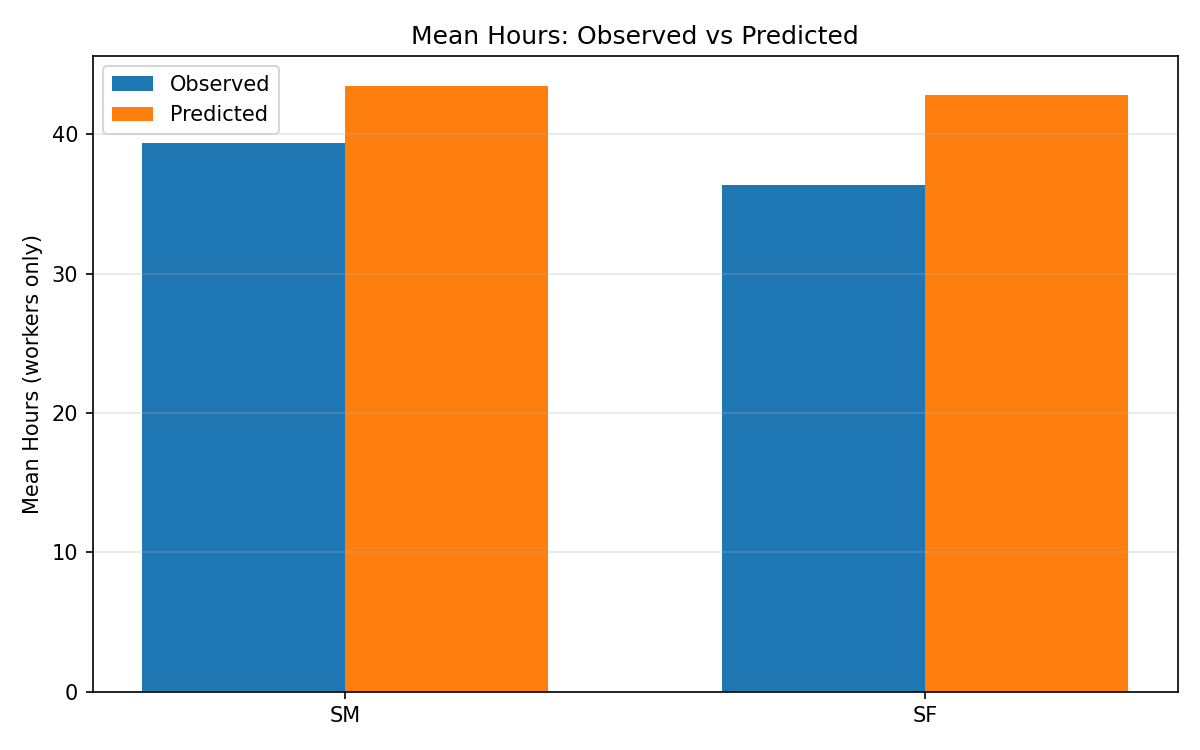

**fit_participation**

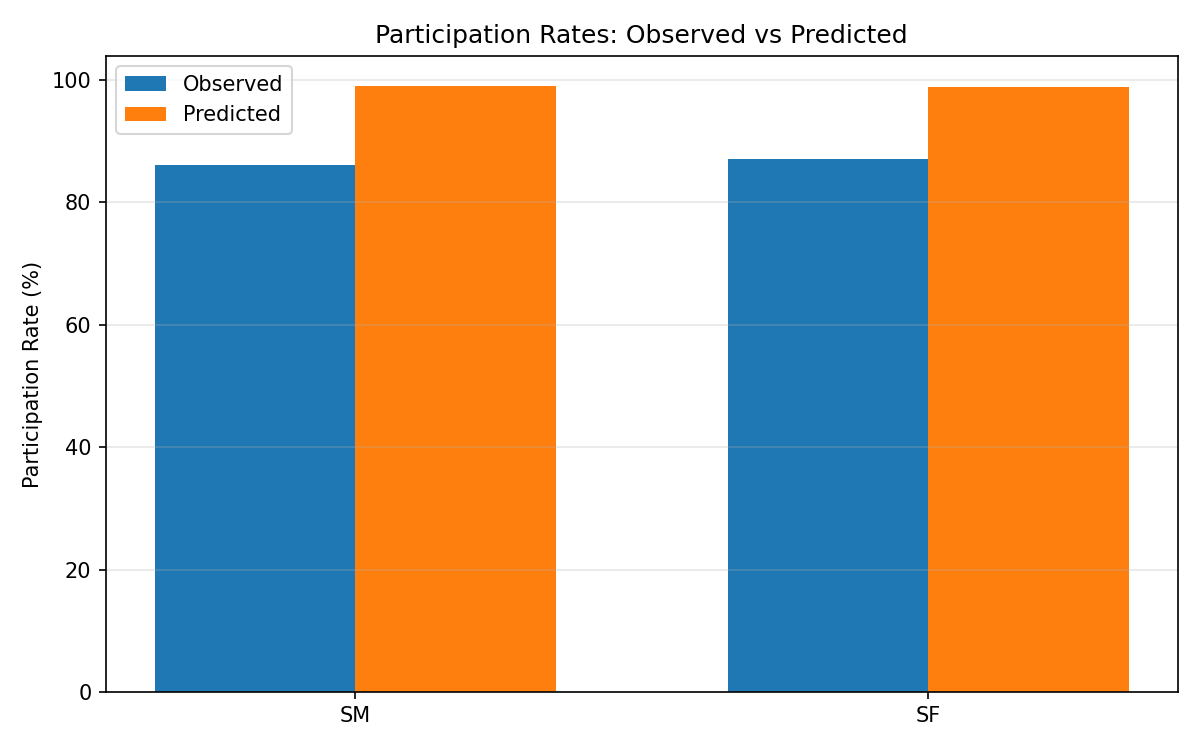

**hours_distribution_singles_female**

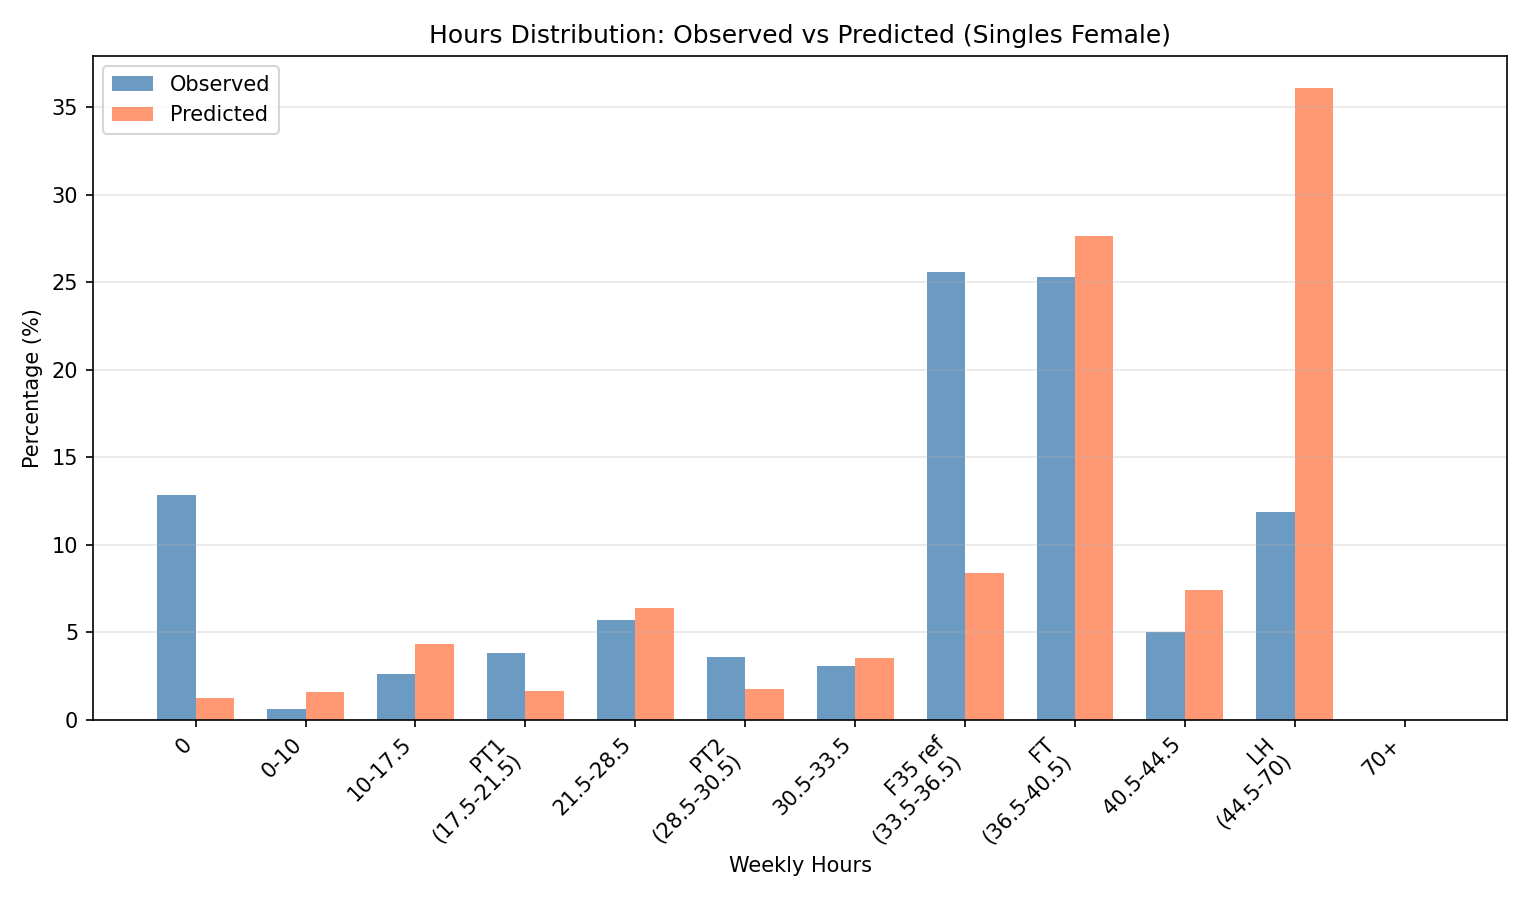

**hours_distribution_singles_male**

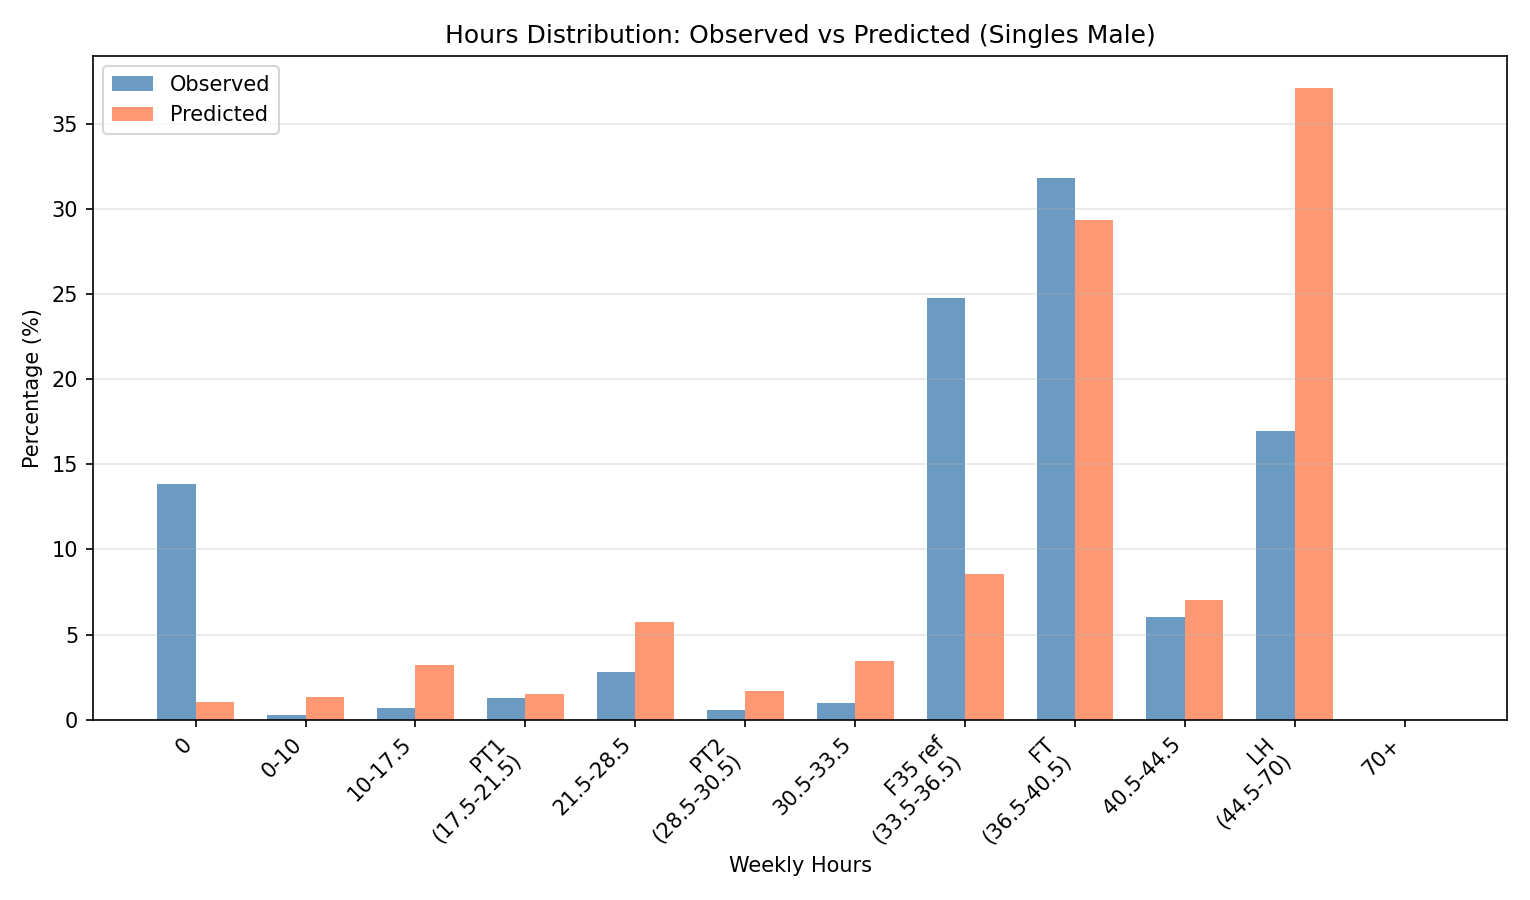

**hours_distribution_total**

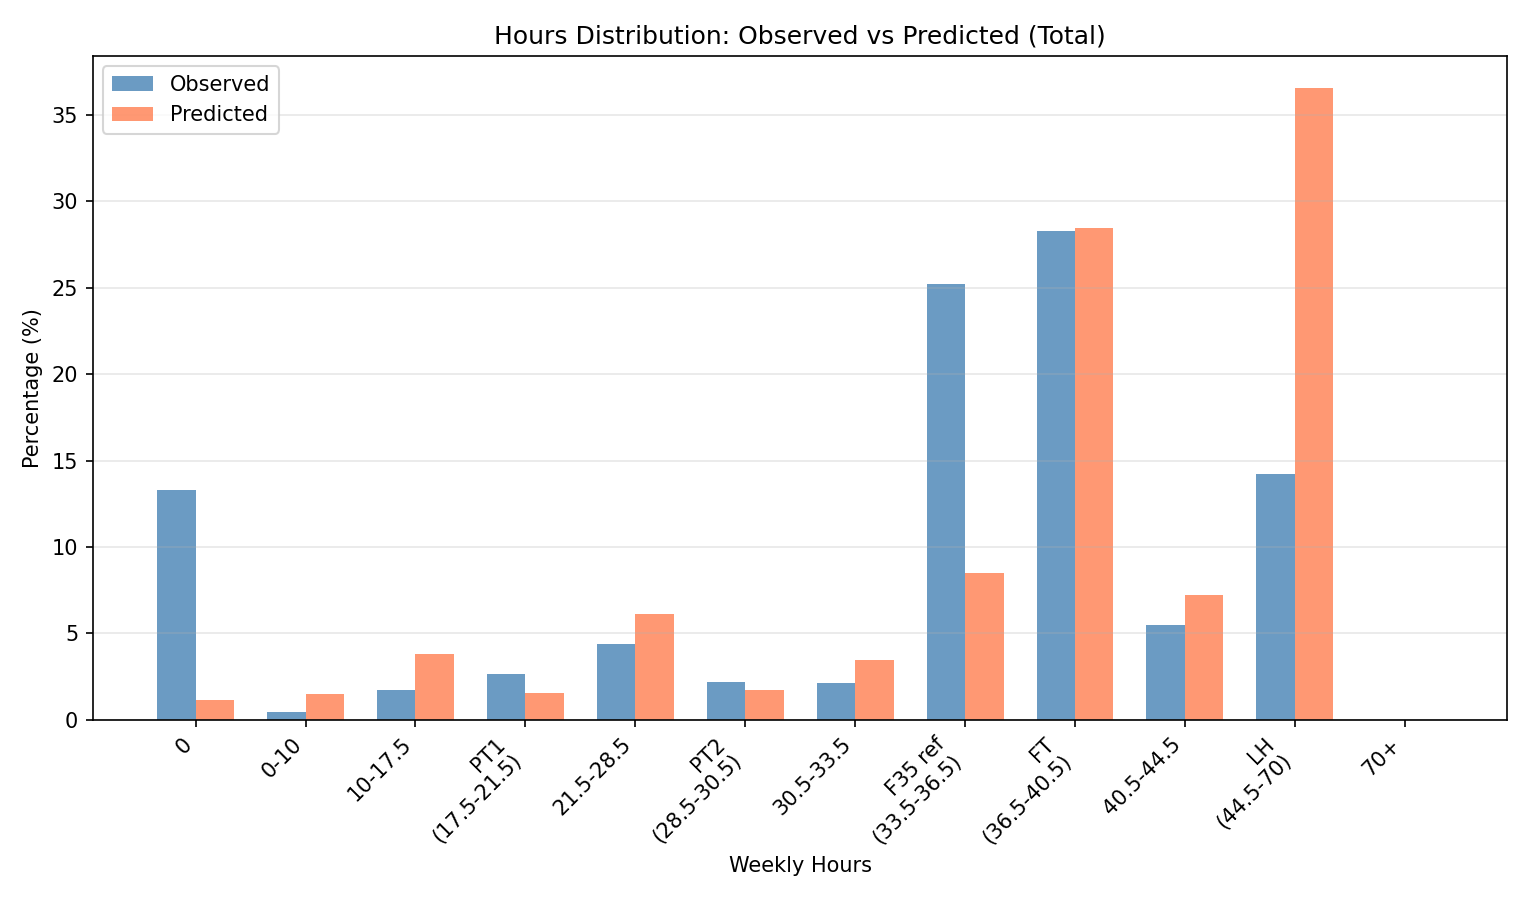

**muc_comparison**

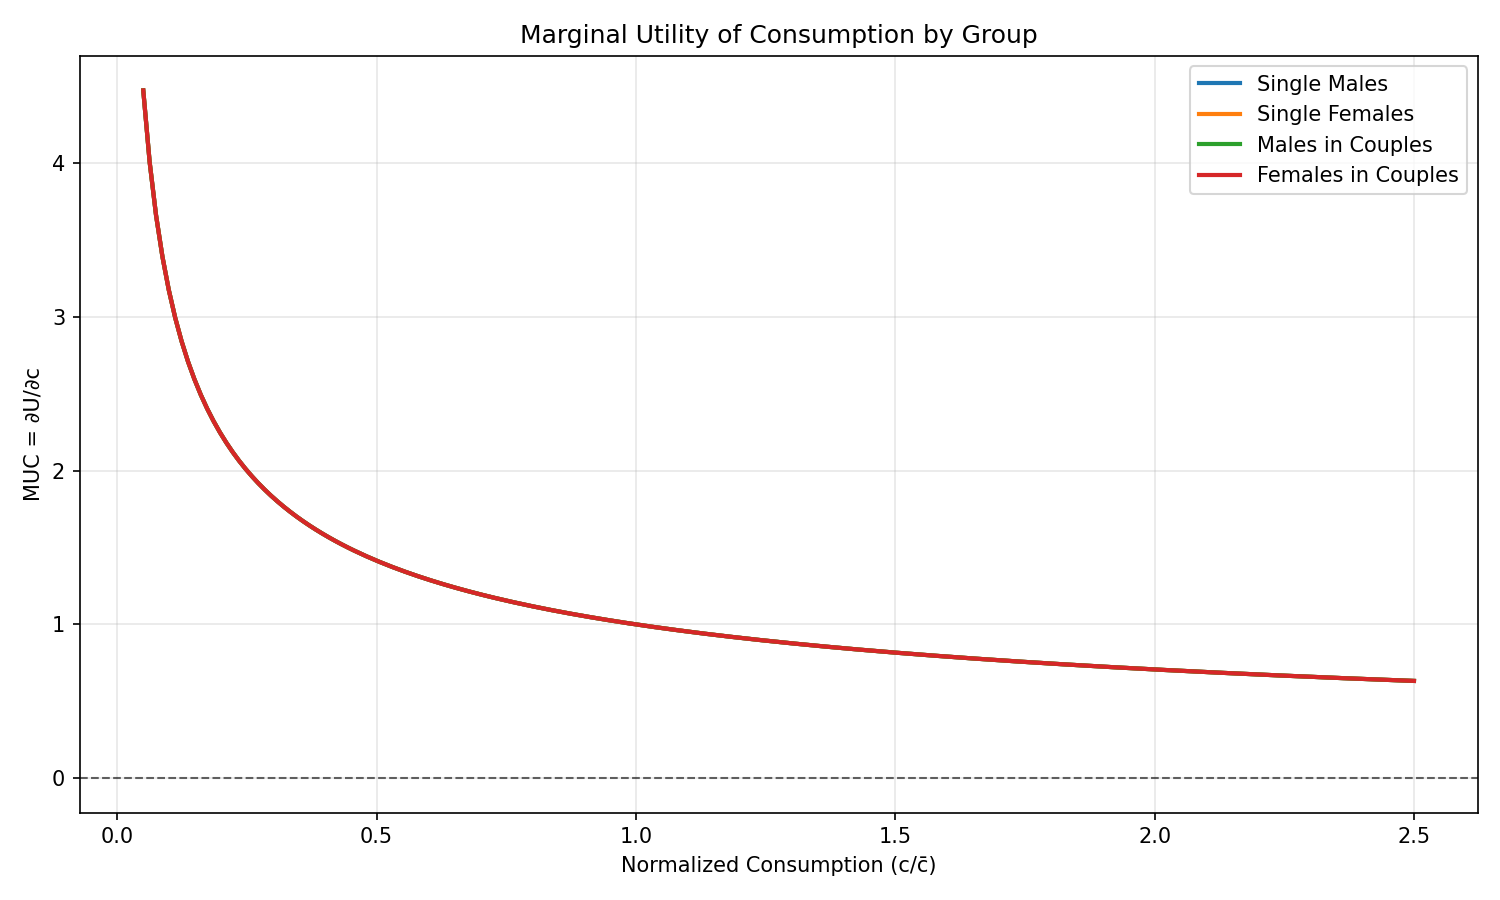

**mul_comparison**

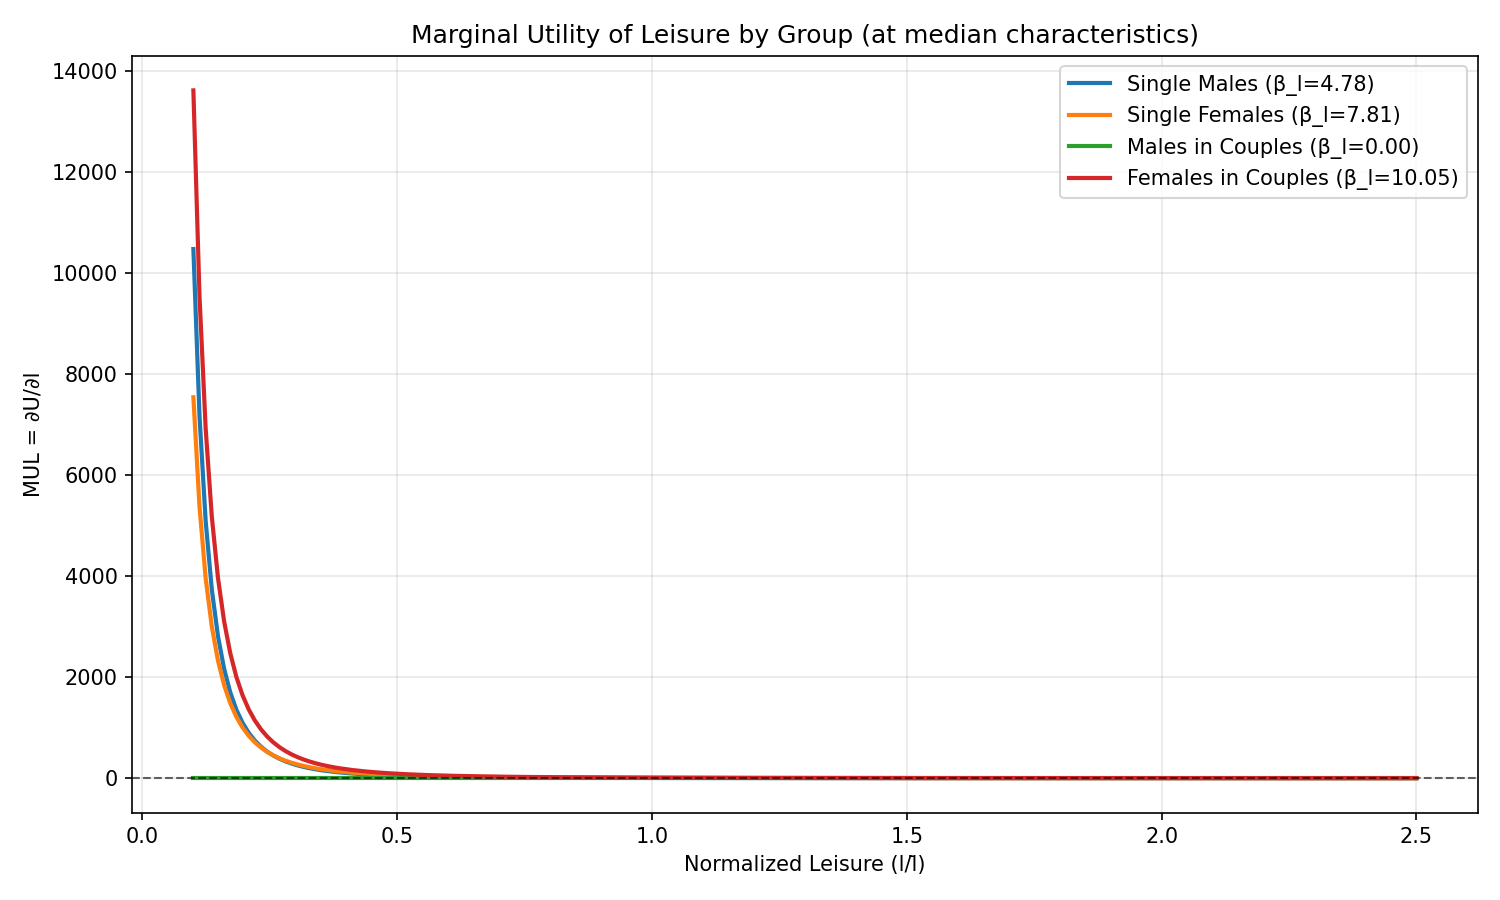

**negative_mu_diagnostics**

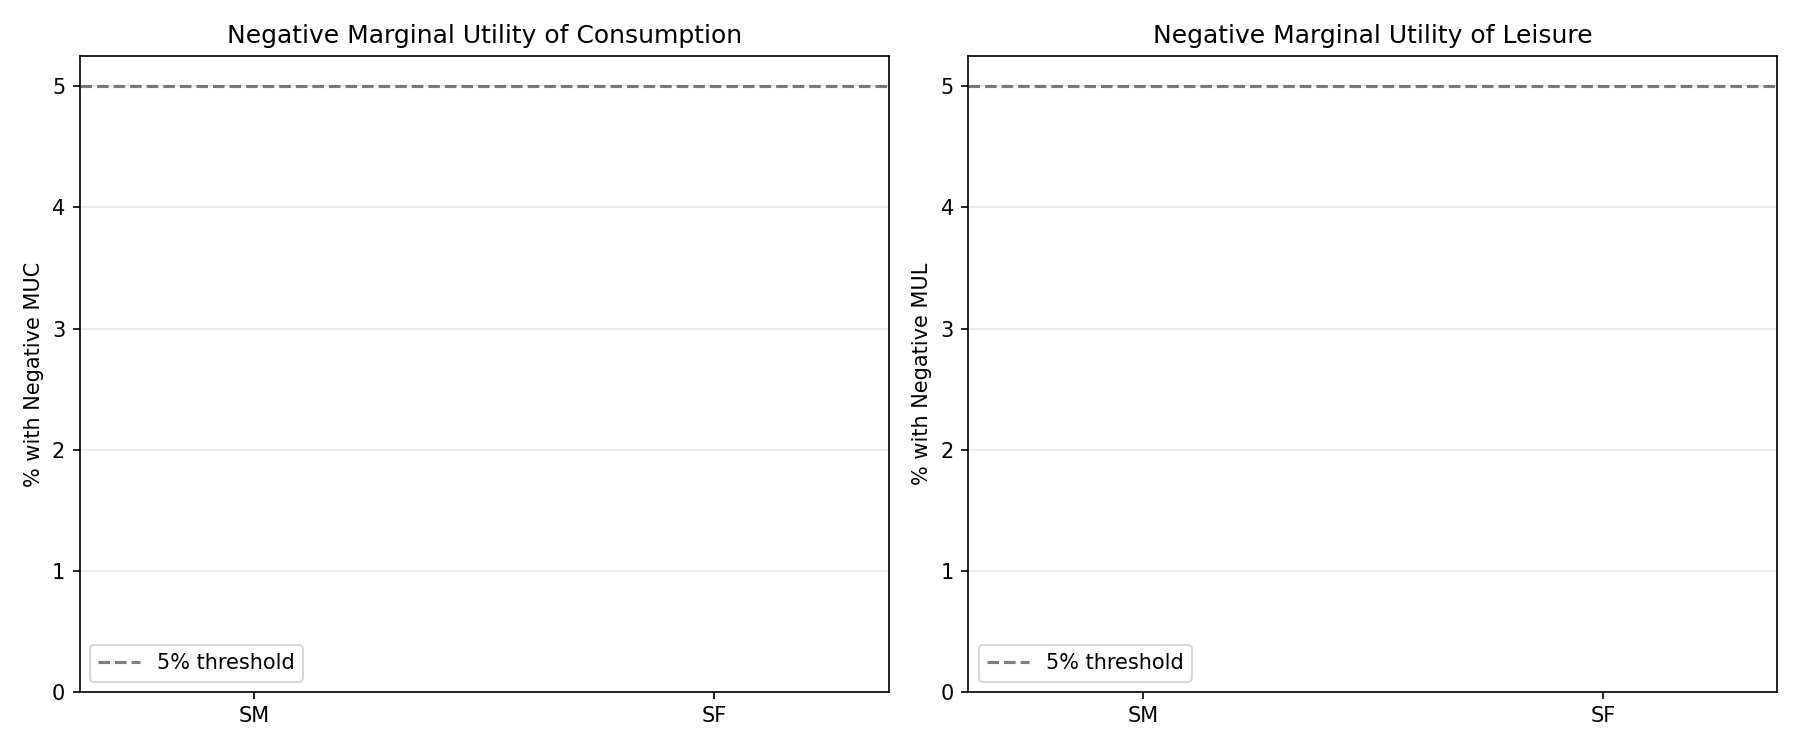

**sf_contours**

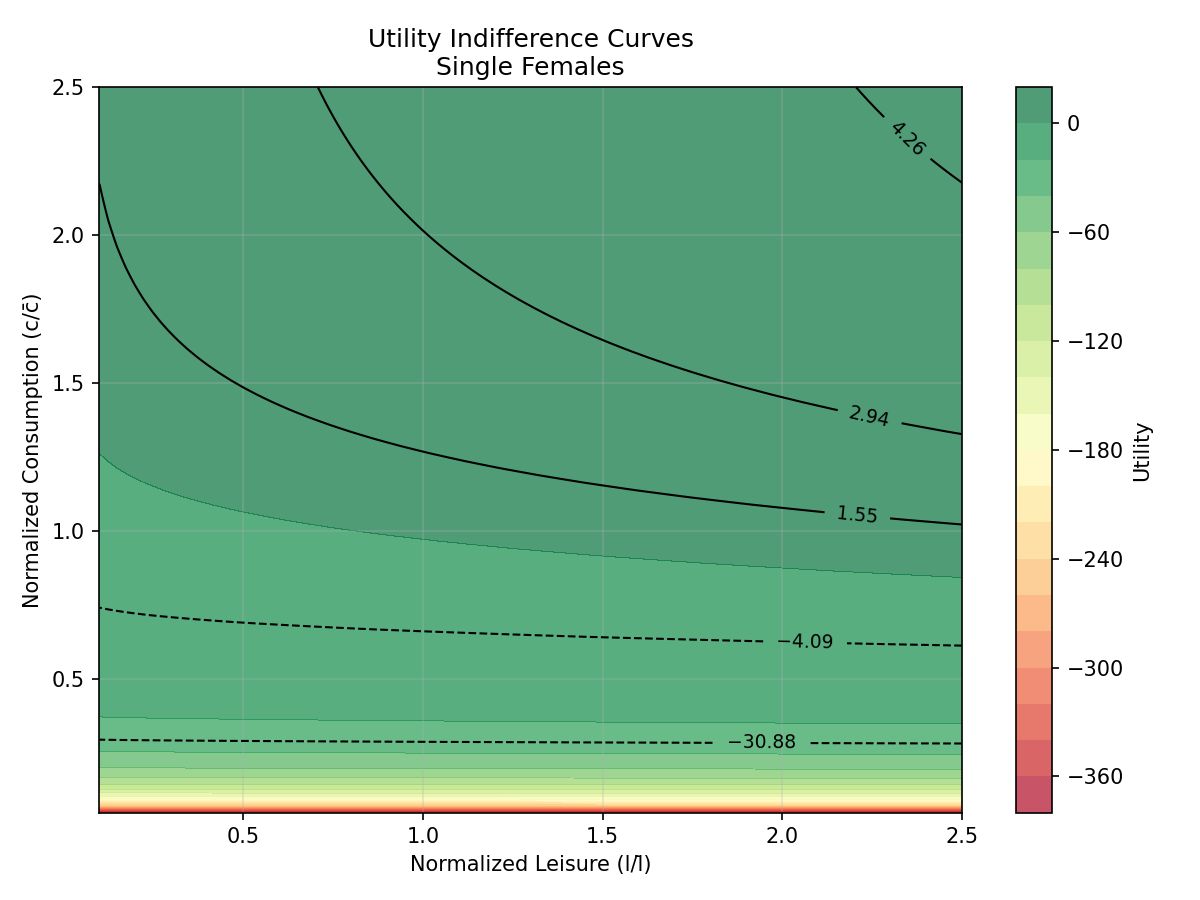

**sf_mu**

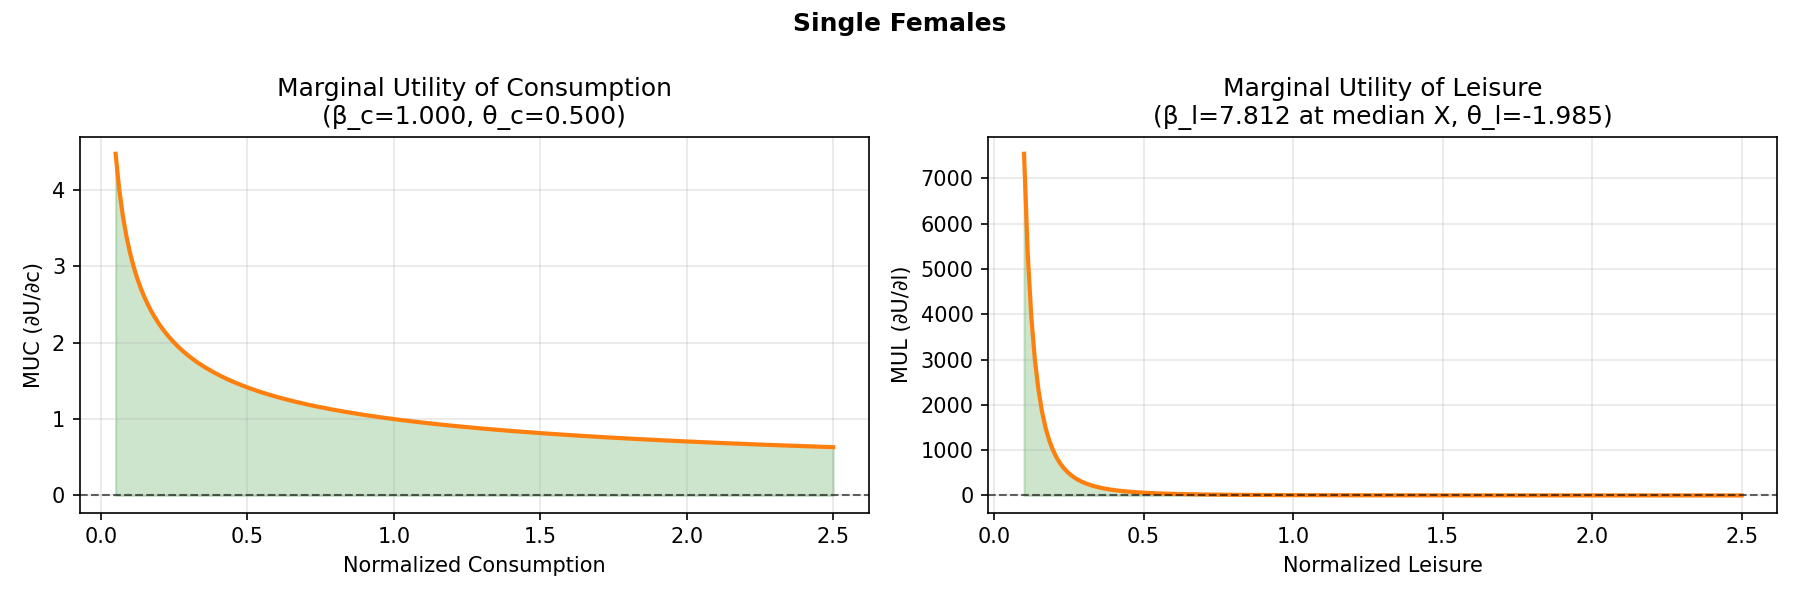

**sm_contours**

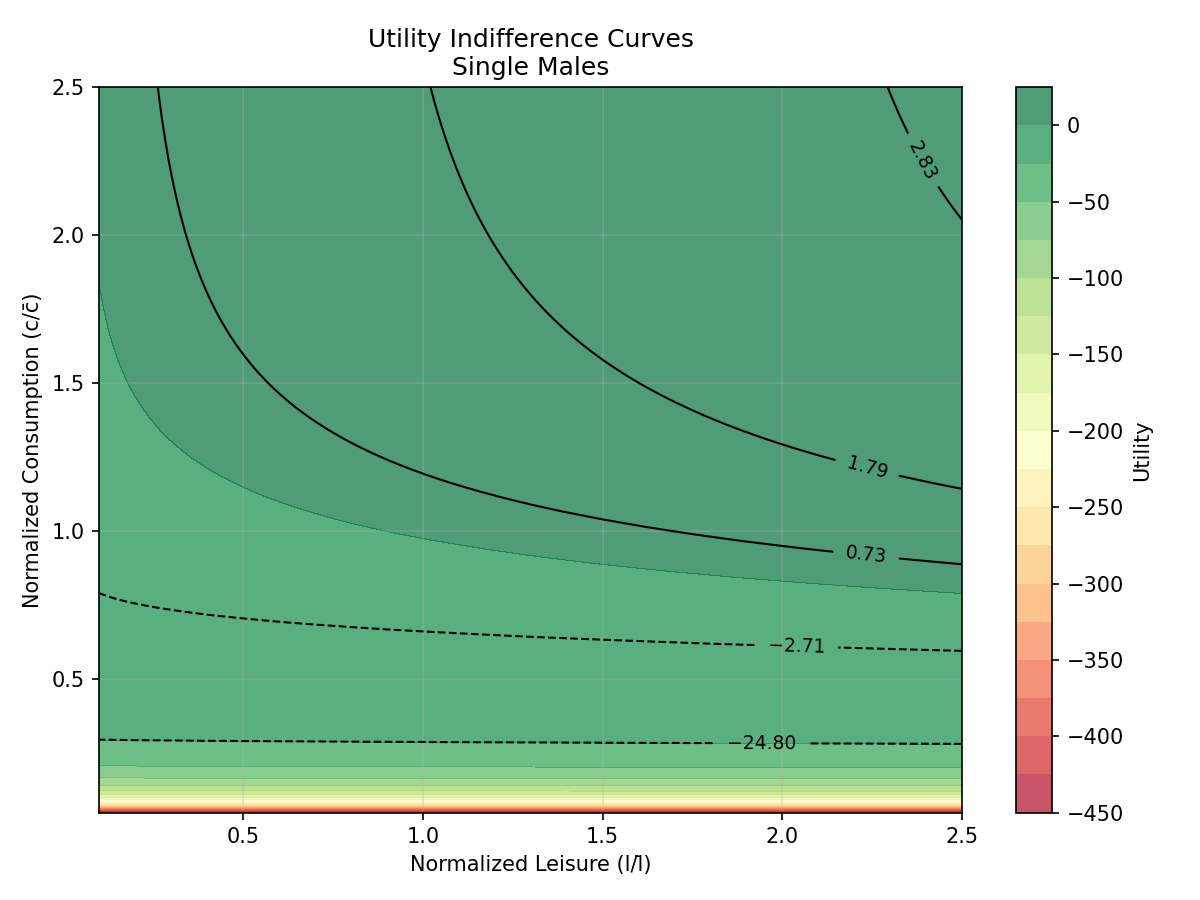

**sm_mu**

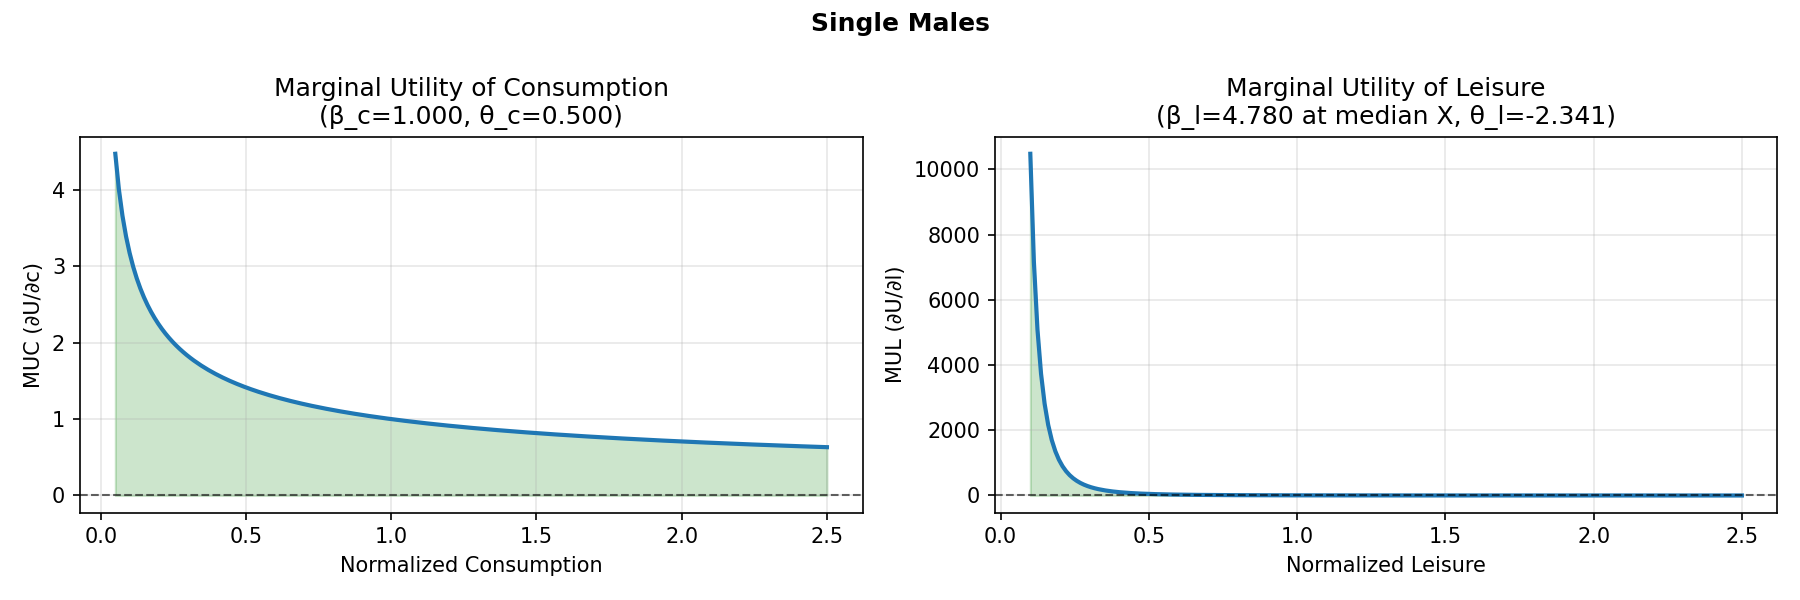

**wage_distribution_singles_female**

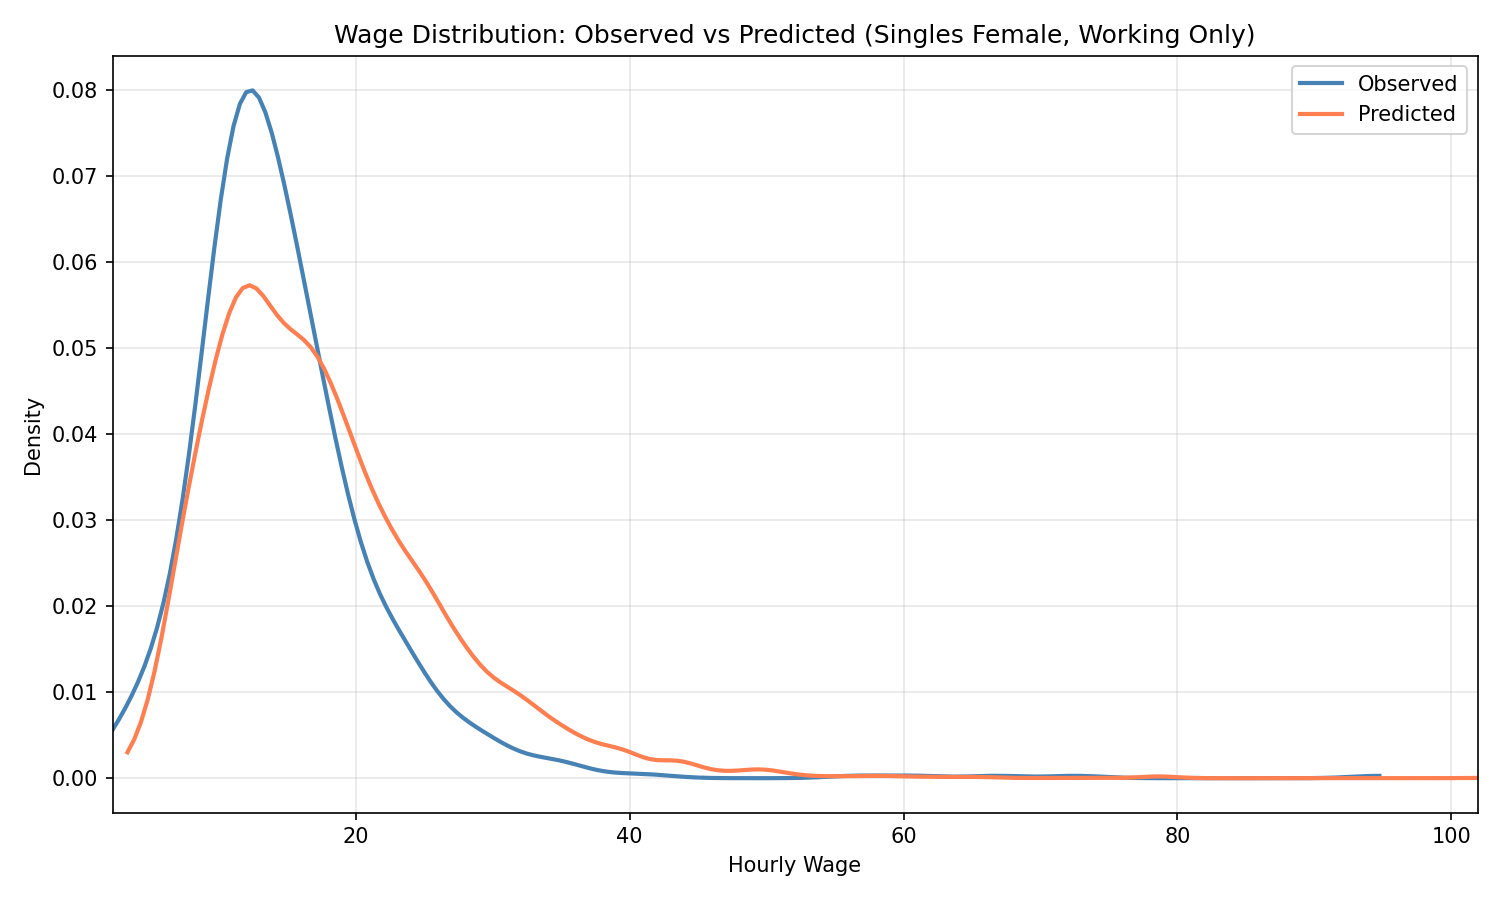

**wage_distribution_singles_male**

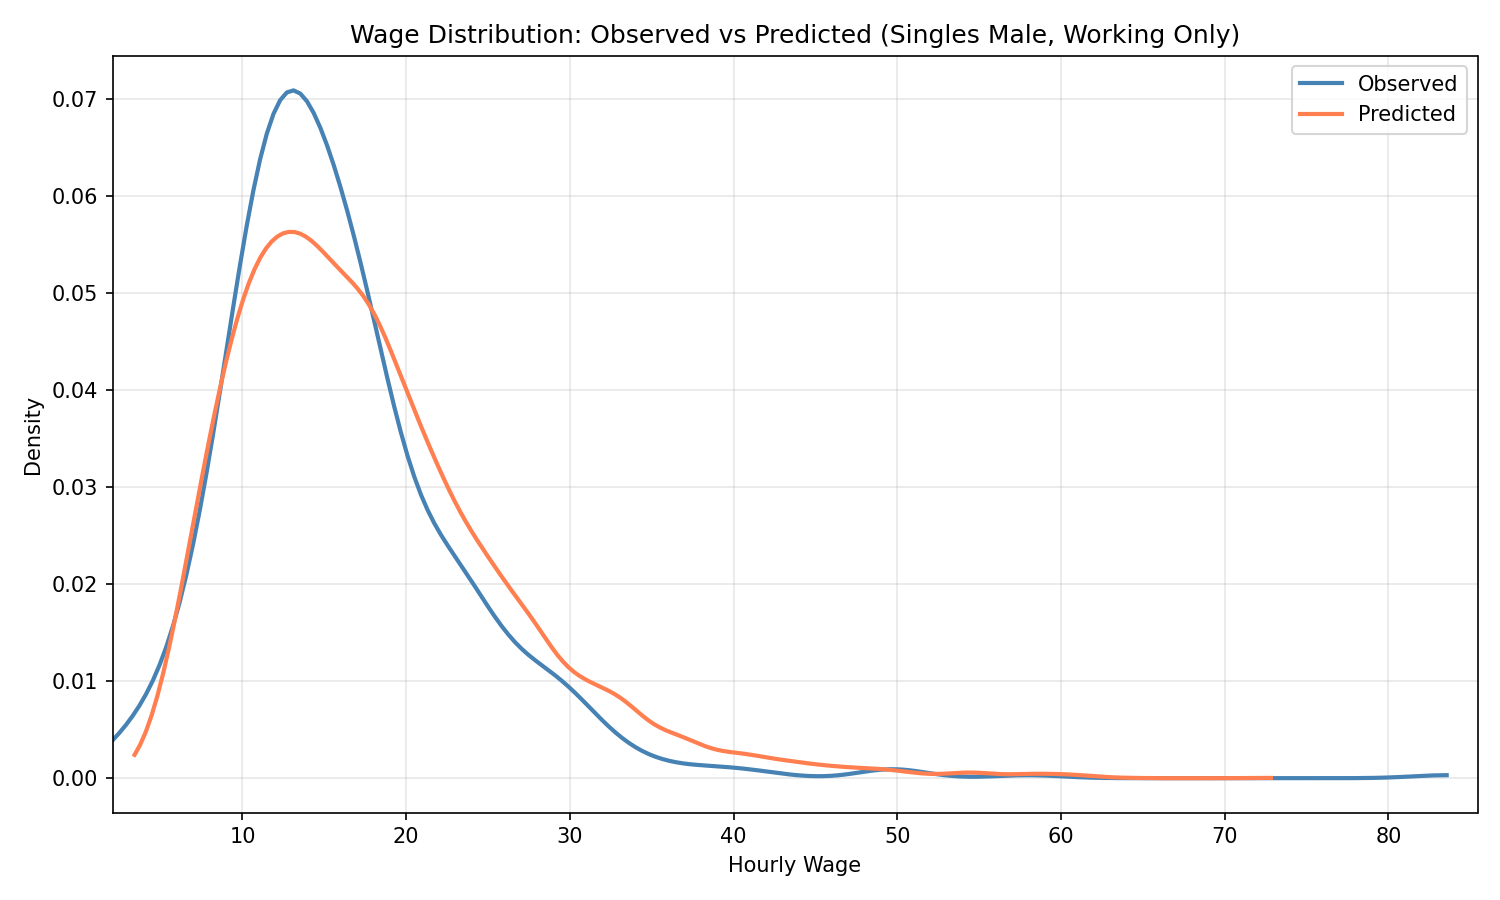

**wage_distribution_total**

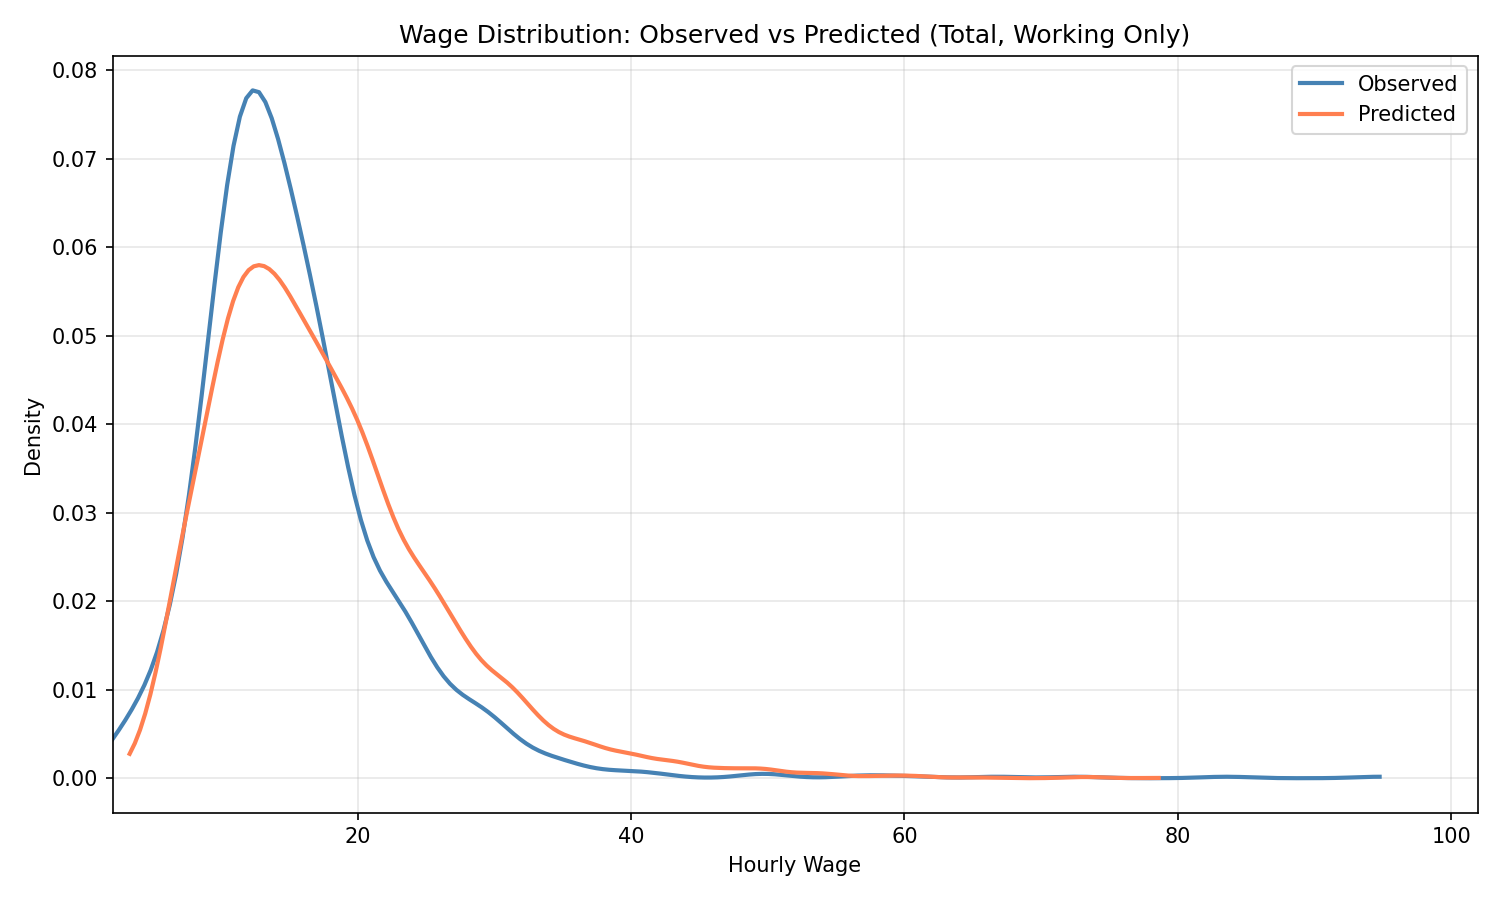

In [31]:
# wrapped so a headless report failure does not abort the pipeline / anchor
try:
    # ── P2a-6. Post-estimation report — INLINE (P2a singles; no HTML kept) ──────
    # Runs RURO_post_estimation_styled.py into the trial folder, then displays the
    # LLM summary + every diagnostic image right here. The *_llm_summary_*.md stays
    # in outputs/p2a_singles2016/; the HTML is discarded (we read it inline).
    import subprocess, sys, glob, os
    from pathlib import Path
    from IPython.display import Image, Markdown, display
    
    candidates = [Path.cwd(), Path.cwd().parent]
    MNL_ROOT = next((p for p in candidates if (p / 'scripts/enhanced/RURO_post_estimation_styled.py').exists()), None)
    if MNL_ROOT is None:
        raise FileNotFoundError('Could not locate MNL repo root (scripts/enhanced/RURO_post_estimation_styled.py).')
    
    OUTDIR = MNL_ROOT / 'outputs/p2a_singles2016'
    PREFIX = 'p2a_singles2016_'
    
    # clean only PRIOR report artifacts (prefix-scoped) so nothing stale is re-displayed;
    # inputs (fr_p2a_singles2016__*, estimation_results_*.json) do NOT match this prefix.
    for pat in (f'{PREFIX}*.png', f'{PREFIX}*.html', f'{PREFIX}llm_summary_*.md'):
        for f in OUTDIR.glob(pat):
            f.unlink()
    
    cmd = [
        sys.executable, 'scripts/enhanced/RURO_post_estimation_styled.py',
        '--results-json', 'outputs/p2a_singles2016/estimation_results_p2a_singles2016.json',
        '--mnl-base',     'outputs/p2a_singles2016/fr_p2a_singles2016',
        '--spec-config',  'scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml',
        '--output-dir',   'outputs/p2a_singles2016',   # PNGs land flat in the trial folder
        '--no-spec-subdir',                              # ...not a spec subdir
        '--llm-summary-dir', 'outputs/p2a_singles2016',
        '--prefix',       PREFIX,
        '--cluster-col',  'idorighh',
    ]
    print('running:', ' '.join(cmd))
    r = subprocess.run(cmd, cwd=MNL_ROOT, capture_output=True, text=True)
    tail = '\n'.join((r.stdout + r.stderr).splitlines()[-15:])
    print(tail)
    if r.returncode != 0:
        raise RuntimeError(f'post-estimation failed (exit {r.returncode}) — full stderr above')
    
    # discard the HTML (we render everything inline) and the couples PNGs (no couples
    # data in this P2a singles -> pure redundancy, don't leave them on disk either)
    for h in OUTDIR.glob(f'{PREFIX}*.html'):
        h.unlink()
        print('removed HTML:', h.name)
    for cp in list(OUTDIR.glob(f'{PREFIX}cou_*.png')) + list(OUTDIR.glob(f'{PREFIX}couples*.png')):
        cp.unlink()
    
    # 1) LLM summary markdown, inline
    md_files = sorted(OUTDIR.glob(f'{PREFIX}llm_summary_*.md'), key=os.path.getmtime)
    if md_files:
        print(f'\nkept summary: {md_files[-1].relative_to(MNL_ROOT)}')
        display(Markdown(md_files[-1].read_text(encoding='utf-8')))
    else:
        print('WARNING: no *_llm_summary_*.md produced')
    
    # 2) diagnostic images inline, deduped + sorted. Singles trial -> DROP the couples
    # plots (cou_m/cou_f *_mu, *_contours): they are driven only by the pinned couples
    # params, have no couples microdata behind them, and are pure redundancy here.
    def _is_couples(stem):
        s = stem[len(PREFIX):]
        return s.startswith('cou_') or s.startswith('couples') or '_couples' in s
    allpng = sorted({p.resolve() for p in OUTDIR.glob(f'{PREFIX}*.png')}, key=lambda p: p.name)
    pngs = [p for p in allpng if not _is_couples(p.stem)]
    dropped = [p.stem[len(PREFIX):] for p in allpng if _is_couples(p.stem)]
    if dropped:
        print(f'\nsuppressed {len(dropped)} couples plot(s) (no couples data in this P2a singles run): {dropped}')
    print(f'{len(pngs)} singles diagnostic image(s):')
    for p in pngs:
        display(Markdown(f'**{p.stem[len(PREFIX):]}**'))
        display(Image(filename=str(p)))
except Exception as _e:
    print('report step skipped:', type(_e).__name__, _e)

## 18. Master record + regression anchor

In [32]:
# ── P2a-8. P2a master record + regression anchor (target 19053.4655, region-live) ────────
# Clones the trial's master-record (box 25) and anchor (box 27) with P2a numbers,
# all read from p2a_fit_provenance.json (no hardcoded diagnostics).
import json
from dclaborsupply.data.loader import load_singles
from dclaborsupply.likelihood.index import compute_index

_prov  = json.load(open('p2a_fit_provenance.json'))
_negll = float(_prov['negll_fit'])
_theta_c = float(r_b.x[idx['theta_c_singles']])

md = f"""# FR 2016 Singles RURO — P2a Rebuild Master Record
Sample: 1,555 single households (20-60), FR_2016_a3, certified B-pool draws ({_prov['n_alts']} alts/HH).
negLL fit **{_negll:.4f}** (37 free / 10 pinned / 2 at-bound; occupation block ESTIMATED, not pinned).
## What changed vs the trial (negLL 4106.6042; occ pinned; uniform proposals)
1. Draws design: {_prov['draws_design']}.
2. Band convention: {_prov['band_convention']}.
3. Occupation block FREE and identified; region/urbanisation/gsur revived from zero-stubs (negLL 19071.6562 -> 19053.4655; beta_E absorbed the regional variation).
4. theta_c_singles = {_theta_c:.4f}.
## Verdict artifacts (outputs/p2a_singles2016/)
- P2a-6 inline report: the hours-distribution figure is the rebuild verdict (target: the 33.5-36.5 band recovering toward the observed ~25%).
- P2a-7 SEs: p2a_se_clustered.csv (sandwich, analytic scores, cluster=idorighh; occupation-block SEs included).
- results JSON + *_llm_summary_*.md + PNGs in the same folder.
## Provenance
{_prov['theta_csv']} | p2a_fit_provenance.json | {_prov['engine_ready']}
"""
open('outputs/p2a_singles2016/P2A_MASTER_RECORD.md', 'w').write(md)
print('wrote outputs/p2a_singles2016/P2A_MASTER_RECORD.md')

# ── regression anchor — cold reload from provenance, numpy backend ──
_tab  = pd.read_csv(_prov['theta_csv']).set_index('param')['trial']
_er   = pd.read_parquet(_prov['engine_ready'])
_meta = {'normalization': {'singles': {'c_scale': float(_er['c_scale'].iloc[0]),
                                       'l_scale': float(_er['l_scale'].iloc[0])}}}
_dm = load_singles(_er[pd.to_numeric(_er['dgn'])==1].reset_index(drop=True), spec, is_male=True,  metadata=_meta)
_df = load_singles(_er[pd.to_numeric(_er['dgn'])==0].reset_index(drop=True), spec, is_male=False, metadata=_meta)
_th = np.array([float(_tab[n]) for n in spec.all_param_names])
_nll = float(compute_index(spec, (_dm, _df, None), _th, ruro=True, backend='numpy'))
print(f'anchor negLL = {_nll:.6f}  (target 19053.4655, region-live)')
assert abs(_nll - 19053.4655) < 1e-2, 'P2a ANCHOR BROKEN — environment/package/data changed'
print('P2a ANCHOR HOLDS — notebook self-verified.')


wrote outputs/p2a_singles2016/P2A_MASTER_RECORD.md


anchor negLL = 19053.465532  (target 19053.4655, region-live)
P2a ANCHOR HOLDS — notebook self-verified.


## 19. Welfare — V_i^IS + W-measure family (P3-1)

Produce, on this region-live P2a baseline, the ex-ante attained utility `V_i^IS` (household inclusive
value `log Σ_j exp(V_j)`, normalized `V_actual = V_i^IS − log(101)`) and the welfare-measure family
**W1/W3/W4/W6**, plus the survey-weighted inequality battery (Gini, CV², Theil-L, Atkinson). This runs
the two committed tools — `scripts/welfare/stage_p2a_singles_welfare.py` (stages the frozen baseline
into the loader layout: `stacked_hh_uid=idhh`, `year_tag=2`) and `scripts/welfare/run_p2a_singles_welfare.py`
(the measures + inequality) — then verifies the outputs are region-live. Outputs land under
`<EUROMOD-STORAGE>/outputs/welfare/p2a_singles2016/`.

In [33]:
# Run the welfare pair on the frozen region-live baseline (cwd is the repo root, set in cell 1).
import subprocess, sys, os
for _script in ('scripts/welfare/stage_p2a_singles_welfare.py',
                'scripts/welfare/run_p2a_singles_welfare.py'):
    print('=== running', _script, '===')
    _r = subprocess.run([sys.executable, _script], cwd=os.getcwd(), capture_output=True, text=True)
    print('\n'.join((_r.stdout + _r.stderr).splitlines()[-16:]))
    if _r.returncode != 0:
        raise RuntimeError(f'{_script} failed (exit {_r.returncode}) — see output above')

=== running scripts/welfare/stage_p2a_singles_welfare.py ===


P3-1 staging start
  parquet: 157055 rows, 1555 HH, alts/HH=101, year_tag=[2], c_scale=1911.108, l_scale=10.000
  theta: 47 params -> theta_hat_p2a_singles2016_v1.csv; xcheck vs trial col: max_abs=0.00e+00 (matched 47, pass=True)
P3-1 staging done
=== running scripts/welfare/run_p2a_singles_welfare.py ===


P3-1 runner start
  [theta_star] loaded 47/47 params from theta_hat_p2a_singles2016_v1.csv
  theta_hash=7dbf035a5769146a  c_scale=1911.108  l_scale=10.000
  singles_male: n=714 parity=1.78e-15 W3|max|=2.40e-10 W1med=1230 W4med=7176 W6med=7490
  singles_female: n=841 parity=1.78e-15 W3|max|=1.83e-10 W1med=1456 W4med=9593 W6med=10947

--- VERIFICATION ---
  n_hh_ok: True
  V_i_all_finite: True
  viis_parity_ok: True
  W3_zero_recovery_ok: True
  gini_in_unit_interval: {'W1': True, 'W4': True, 'W6': True}
  ALL_PASS: True

  wrote: singles_ViIS_p2a_v1.parquet, singles_measures_p2a_v1.parquet, inequality_p2a_v1.json, run_manifest_p2a_v1.json, RURO_welfare_P2a_singles_Vi_and_measures_report_v1.md
P3-1 runner done in 2.1s  (PASS=True)


In [34]:
# P3-1 verification: confirm the welfare run consumed the region-live baseline.
import json, pandas as pd
from pathlib import Path

d = json.load(open('outputs/p2a_singles2016/estimation_results_p2a_singles2016.json'))
ll = d['results']['joint']['final_ll']
print('results JSON final_ll:', ll,
      '->', 'REGION-LIVE (correct)' if abs(ll + 19053.4655) < 0.01 else 'REGION-DEAD (stale!)')

STORE = Path(r'C:\Users\hisham\MNL\EUROMOD-STORAGE')
staged = pd.read_parquet(STORE / 'new_data' / 'fr_p2a_singles2016_welfare__singles.parquet',
                         columns=['idhh', 'drgn1', 'gsur'])
print('staged parquet region-live?', staged['drgn1'].nunique() > 1, '| gsur live?', staged['gsur'].nunique() > 1)

man = json.load(open(STORE / 'outputs/welfare/p2a_singles2016/run_manifest_p2a_v1.json'))
print('welfare theta_hash:', man['theta_hash'], '| ALL_PASS:', man['verification']['ALL_PASS'])
ineq = json.load(open(STORE / 'outputs/welfare/p2a_singles2016/inequality_p2a_v1.json'))
for W in ('W1', 'W4', 'W6'):
    p = ineq['pooled_headline'][W]
    print(f'  {W}: weighted mean {p["weighted_mean"]:.0f} EUR | Gini {p["gini"]:.4f}')

results JSON final_ll: -19053.46553160094 -> REGION-LIVE (correct)
staged parquet region-live? True | gsur live? True
welfare theta_hash: 7dbf035a5769146a | ALL_PASS: True
  W1: weighted mean 1417 EUR | Gini 0.1757
  W4: weighted mean 9333 EUR | Gini 0.2610
  W6: weighted mean 10302 EUR | Gini 0.2664


## 20. On the trial anchor (dropped)

The exploratory notebook carried a **second** regression anchor at trial negLL **4106.604220**. Its
inputs — `fr_singles_engine_ready_v5.parquet` and `trial_fit_provenance.json` — come from the
**superseded** path (uniform draws, occupation block pinned, assembled bands), which this clean
notebook deliberately does not produce (Rule 3). Per the task rule, only the **P2a anchor** (§18) is
kept here. To re-verify the trial anchor, run the historical `fr_data_walkthrough.ipynb`.

## Appendix — dropped cells (from `fr_data_walkthrough.ipynb`)

Every source cell not carried here, with the reason. "SUPERSEDED" = belongs to a superseded
estimation round (uniform draws / occ-pinned fit / assembled bands / trial engine-ready v-chain)
and must not survive (Rule 3). "Diagnostic" = one-off probe whose conclusion is folded into a kept
cell or a decision markdown. "Folded" = logic kept, but merged into a single clean cell.

| src cell | disposition | reason |
|---|---|---|
| 28 | dropped | API-discovery `show_api` probe — replaced by explicit imports |
| 29 | dropped | `generate_draws_long` probe on 5 rows |
| 30 | dropped | **SUPERSEDED** — uniform-proposal draws (replaced by certified B-pool, §9) |
| 31 | dropped | superseded — canonicalize the uniform draws |
| 32 | dropped | diagnostic — yem00/yemxp 35h split probe (finding folded into `fr_earnings_policy`) |
| 33 | folded | FR earnings policy → pricing-setup cell (§10); verification prints dropped |
| 34 | folded | baseline/single_idhh → pricing-setup (§10); the 5-hh smoke test dropped |
| 35 | dropped | diagnostic — batch-relativity per-draw sweep |
| 36 | folded | pricing SETUP (baseline_full/runner_full/policy_v2/hh_all/CHUNK/KEEP) → §10; the trial pricing LOOP dropped (clean prices the P2a draws once) |
| 37 | dropped | diagnostic — revealed take-up crosstab (rates folded into §11) |
| 38 | dropped | diagnostic — bsaot probe |
| 39 | dropped | inspection — `assemble_singles` source print |
| 40 | folded | take-up traits + mask → §11 (recomputed on `priced_p2a` draw 0) |
| 41 | dropped | inspection — assembly-contract print |
| 42 | dropped | inspection — contract/provenance resolve |
| 43 | dropped | **SUPERSEDED** — trial `feat` engine-ready features |
| 44 | dropped | **SUPERSEDED** — trial `assemble_singles` (engine-ready v1) |
| 45 | folded | spec load → §13 (kept: spec/names/warm start; dropped: exploratory attr prints) |
| 46 | dropped | **SUPERSEDED** — engine-ready v2 region revival |
| 47 | folded | gsur construction → §8 (the `singles_dec` merge; the `er_singles` overwrite dropped) |
| 48 | dropped | diagnostic — negLL flatness/liveness probe on the v-chain |
| 49 | dropped | **SUPERSEDED** — engine-ready v4 |
| 50 | dropped | **SUPERSEDED** — engine-ready v5-partial |
| 51 | folded | pexp construction → §8 |
| 52 | dropped | **SUPERSEDED** — engine-ready v5 + trial-baseline probe |
| 53 | dropped | **SUPERSEDED** — trial fit v1 (unpinned) |
| 54 | dropped | **SUPERSEDED** — trial fit v2 (occupation block pinned) |
| 55 | dropped | diagnostic — gradient-mask probe |
| 56 | dropped | **SUPERSEDED** — trial polish fit |
| 57–63 | dropped | **SUPERSEDED** — trial adapter/freeze/report/provenance-guard |
| 64 | dropped | **SUPERSEDED** — trial cluster-robust SEs (P2a SEs kept, §16) |
| 65 | dropped | diagnostic — box-24 conditional-wage arbiter (verdict cited in §14) |
| 66 | dropped | **SUPERSEDED** — trial master record (P2a record kept, §18) |
| 67 | dropped | **SUPERSEDED** — trial verdict patch |
| 68 | dropped | trial regression anchor — inputs not produced here (see §19) |
| 73 | dropped | **SUPERSEDED** — P2a-4 assembled-bands fit (bpool bands kept, §12) |
| 74 | folded | kept the `er_b` bpool-band build (§12); dropped the assembled-vs-bpool fit comparison |

Kept verbatim/adapted: data read, schema, config, classification, funnel 4.0–4.6, features+loc4,
observed pricing (guarded), singles restriction, folded features (§8), P2a-0/P2a-1 draws (§9),
pricing (§10), take-up (§11), assembly+bpool bands (§12), spec (§13), fit (§14), adapter (§15),
SEs (§16), report (§17), record+anchor (§18).